# Predicting Late Delivery Risk in Global Supply Chains

**Author -** Michael Nwuju

## 1. Introduction & Problem Statement

### 1.1 Motivation

The operations of the logistics industry produces huge amounts of transaction data, eg. Orders, delivery window, country, shipping method. A lot of this data however gets to the operation of generating historical reports and does not often feed in to predictive operations. One of the most costly and most frequent operational fails that every supply chain encounters is the late delivery.

A late delivery damages your relationship with the customer, creates claims and refunds and generally blocks up the system by holding up a dock with an existing delayed order when it is now time to process the new order.

If the business had the ability to identify that at the point of order creation that there is a high risk of that order being late, operations team would be able to take immediate action (re-shipping via a new route, re-routing over a quicker, but maybe more expensive, shipping method or at the very least advising the customer to expect a delay). This project addresses this question as a supervised machine learning project as a use case to contrast traditional machine learning approaches (Scikit-learn) against deep learning methods (TensorFlow and using both the Sequential and Functional APIs in conjunction with the tf.data input pipeline API).

### 1.2 Problem Statement / Research Question

> **Given information available at order time (product, customer segment, market/region, shipping mode chosen, order timing, and order economics), can we predict whether an order will be subject to late delivery (`Late_delivery_risk = 1`) versus on-time/advance delivery (`Late_delivery_risk = 0`)?**

It is deliberately phrased as an *order-time* prediction problem. The raw dataset also has fields that identify what actually happened with the shipping (like the true number of shipping days, the final delivery status). That information  cannot be used as legitimate predictor for this problem - a model that would uses them would be pretty much useless for real, because you don’t know the actual outcome when you accept the order. Discarding that type of target leakage is one of the first decisions I make in this notebook (Section 4).

### 1.3 Dataset Overview

We use the **DataCo Smart Supply Chain for Big Data Analysis** dataset: 180,519 order-line records spanning five global markets (LATAM, Europe, Pacific Asia, USCA, and **Africa**), each described by ~50 fields covering customer demographics/segment, product category, order economics (price, discount, profit), shipping mode, and geography. The dataset is **not** one of the sklearn/keras toy datasets — it is a realistic, messy, large tabular dataset typical of what a logistics analytics team would actually work with (mixed types, missing values, encoding quirks, and highly imbalanced categorical fields).

The binary target variable `Late_delivery_risk`, is fairly balanced (54.8% Late and 45.2% Not late / Earlier), so it can tolerate the use of typical classification metrics with light class imbalance corrections - however we still report on precision, recall, F1 and ROC-AUC(not just accuracy) everywhere possible.

### 1.4 Mission Alignment: A Logistics Lens with an Africa Focus

The larger motivation for this project is that shipping and logistics data remains a largely underexploited resource for operational optimization, particularly for regions where the logistics network is not mature. This dataset explicitly provides an Africa market section (with additional fine-graining at the order region level) - which is a relative small one (6.4% of all orders). In the model evaluation section (Section 9, Model Evaluation & Error Analysis), we revisit this region to specifically address how a model developed from a full dataset dominated by North American and European customers behaves for a region with less volume - a key concern for operationalizing ML-based logistics tools in less mature markets.

### 1.5 Notebook Roadmap

1. Introduction & Problem Statement *(this section)*
2. Setup & Reproducibility
3. Exploratory Data Analysis (EDA)
4. Data Cleaning & Feature Engineering (incl. leakage analysis)
5. Preprocessing Pipeline & Train/Validation/Test Split
6. Classical Machine Learning Experiments (Scikit-learn)
7. Deep Learning Experiments (TensorFlow: `tf.data`, Sequential API, Functional API)
8. Consolidated Experiment Results Table
9. Model Evaluation & Error Analysis (learning curves, confusion matrices, ROC curves, bias–variance, segment analysis)
10. Conclusion & Future Work

## 2. Setup & Reproducibility

This section imports all libraries used in the notebook, fixes random seeds across `random`, `numpy`, and `tensorflow` so results are reproducible.

In [37]:
import os
import random
import urllib.request
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import tensorflow as tf

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [38]:
# Downloads the dataset if not present
DATA_DIR = "../data" if os.path.isdir("../data") else "data"

os.makedirs(DATA_DIR, exist_ok=True)

DATA_FILE = os.path.join(DATA_DIR, "DataCoSupplyChainDataset.csv")

DATA_URL = (
    "https://raw.githubusercontent.com/ashishpatel26/"
    "DataCo-SMART-SUPPLY-CHAIN-FOR-BIG-DATA-ANALYSIS/main/DataCoSupplyChainDataset.csv"
)

if not os.path.exists(DATA_FILE):
    print("Downloading dataset (~91MB)... this may take a minute.\n")

    urllib.request.urlretrieve(DATA_URL, DATA_FILE)

    print("Download complete.")

else:
    print("Dataset already present at", DATA_FILE)

Dataset already present at data/DataCoSupplyChainDataset.csv


## 3. Exploratory Data Analysis (EDA)

We load the raw dataset (note the `latin1` encoding — the file contains non-UTF-8 bytes in some text fields) and examine its shape, data types, missingness, and the distribution of the target variable before making any cleaning decisions.

In [39]:
df_raw = pd.read_csv(DATA_FILE, encoding="latin1")

print("Shape:", df_raw.shape)

print("\n")

df_raw.head()

Shape: (180519, 53)




,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [40]:
info_df = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "n_missing": df_raw.isna().sum(),
    "percentage_missing": (df_raw.isna().mean() * 100).round(2),
    "n_unique": df_raw.nunique(),
})

info_df.sort_values("percentage_missing", ascending=False)

,dtype,n_missing,percentage_missing,n_unique
Product Description,float64,180519,100.00,0
Order Zipcode,float64,155679,86.24,609
Days for shipment (scheduled),int64,0,0.00,4
Days for shipping (real),int64,0,0.00,7
Type,object,0,0.00,4
Delivery Status,object,0,0.00,4
Late_delivery_risk,int64,0,0.00,2
Category Id,int64,0,0.00,51
Category Name,object,0,0.00,50
Customer City,object,0,0.00,563


**Insight:**

`Product Description` is 100% missing (entirely empty column and is safe to drop), `Order Zipcode` is 86% missing (too sparse to impute meaningfully), and `Customer Lname` / `Customer Zipcode` have only a handful of missing values. We will handle each of these explicitly in Section 4. Missingness does not appear to be concentrated in a way to suggest informative missingness (e.g., missingness-not-at-random correlated with the target) for any of the columns that we plan to keep.

### 3.1 Target Variable Distribution

`Late_delivery_risk` is our binary target. `Delivery Status` is the original 4-class field it was derived from, we inspect both to understand the relationship (and confirm why `Delivery Status` would leak the target if kept as a feature).

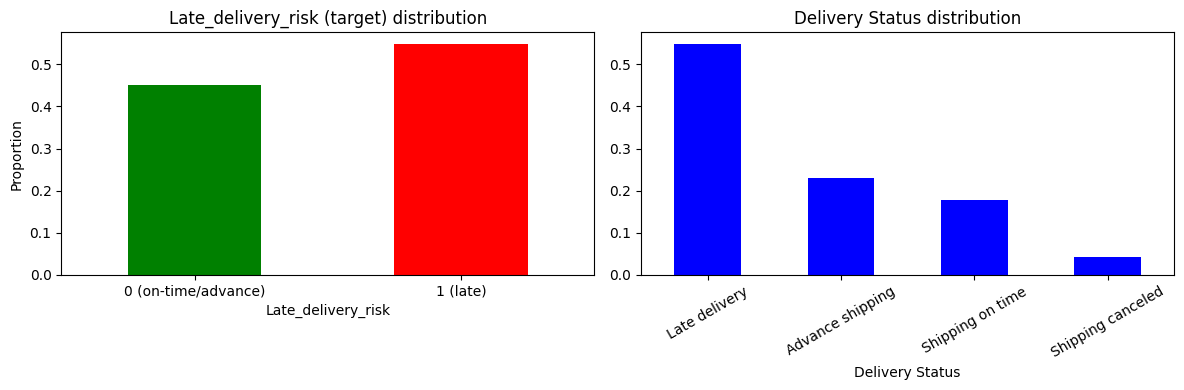

Delivery Status
Advance shipping     [0]
Late delivery        [1]
Shipping canceled    [0]
Shipping on time     [0]
Name: Late_delivery_risk, dtype: object


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_raw["Late_delivery_risk"].value_counts(normalize=True).sort_index().plot(
    kind="bar", ax=axes[0], color=["green", "red"]
)

axes[0].set_title("Late_delivery_risk (target) distribution")

axes[0].set_xlabel("Late_delivery_risk")

axes[0].set_ylabel("Proportion")

axes[0].set_xticklabels(["0 (on-time/advance)", "1 (late)"], rotation=0)

df_raw["Delivery Status"].value_counts(normalize=True).plot(
    kind="bar", ax=axes[1], color="blue"
)

axes[1].set_title("Delivery Status distribution")

axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()

plt.show()

print(df_raw.groupby("Delivery Status")["Late_delivery_risk"].unique())

**Insight:**

The target is well balanced: (late 55% vs on-time/advance/canceled 45%). We see from the output of `groupby` that there is a 1-1 mapping between `Delivery Status` and `Late_delivery_risk`. We see that 'Late delivery' leads to 1 in the target variable and all other values ('Advance shipping', 'Shipping on time', 'Shipping canceled') leads to 0 in the target variable.

This confirms that this feature is just a re-encoding of the target and needs to be dropped because otherwise it is easy to get a perfect prediction by a model just by checking the Delivery Status feature.

### 3.2 Late-Delivery Rate by Market and Region (Africa Focus)

We now consider the late delivery rate by `Market`, and then within that, by `Order Region`, while paying close attention to the sub-regions of Africa (given the mission we are framing).

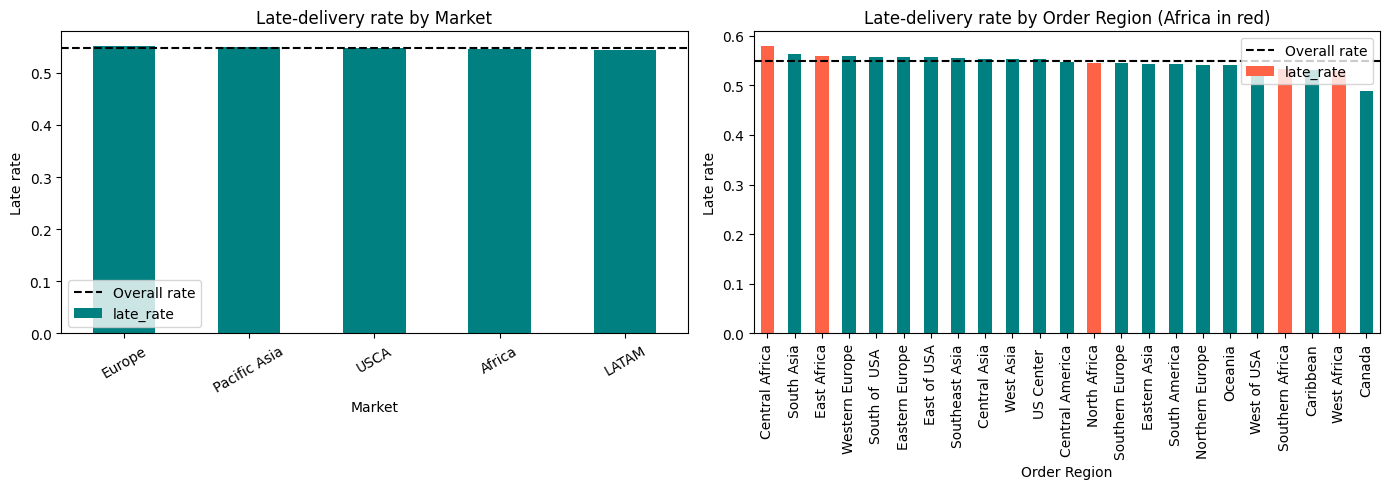

,late_rate,n_orders
Market,,
Europe,0.552078,50252
Pacific Asia,0.550460,41260
USCA,0.548006,25799
Africa,0.545893,11614
LATAM,0.543552,51594


In [42]:
market_rate = (
    df_raw.groupby("Market")["Late_delivery_risk"]
    .agg(late_rate="mean", n_orders="count")
    .sort_values("late_rate", ascending=False)
)

region_rate = (
    df_raw.groupby("Order Region")["Late_delivery_risk"]
    .agg(late_rate="mean", n_orders="count")
    .sort_values("late_rate", ascending=False)
)

africa_regions = [region for region in region_rate.index if "Africa" in region]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

market_rate["late_rate"].plot(kind="bar", ax=axes[0], color="teal")

axes[0].axhline(df_raw["Late_delivery_risk"].mean(), color="black", linestyle="--", label="Overall rate")

axes[0].set_title("Late-delivery rate by Market")

axes[0].set_ylabel("Late rate")

axes[0].legend()

axes[0].tick_params(axis="x", rotation=30)

colors = ["tomato" if r in africa_regions else "teal" for r in region_rate.index]

region_rate["late_rate"].plot(kind="bar", ax=axes[1], color=colors)

axes[1].axhline(df_raw["Late_delivery_risk"].mean(), color="black", linestyle="--", label="Overall rate")

axes[1].set_title("Late-delivery rate by Order Region (Africa in red)")

axes[1].set_ylabel("Late rate")

axes[1].legend()

axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()

plt.show()

market_rate

**Insight:**

Overall late rate varies by much less from market to market - within a range of 54.4%(LATAM) - 55.2%(Europe) where Africa’s rate 54.6% is almost identical to the global average 54.8% - with a sample of 11,614 orders that make up 6.4% of our dataset. It is therefore obvious from the table above that Africa is not an outlier in terms of lateness - but what we should be concerned about (see Section 9 - "Fairness"), is Africa's small 2,587 orders, which makes up less than 1.5% of the entire sample. A model based primarily on the other four markets may underestimate and/or overestimate this smaller subgroup and have an seemingly 'normal' late rate aggregate, due to its own high lateness and/or lateness patterns.

### 3.3 Late-Delivery Rate by Shipping Mode and Order Status

`Shipping Mode` is a decision made at order time (the customer/operations team selects a shipping tier), so it is a legitimate predictive feature, and ideally should be one of the strongest signals.

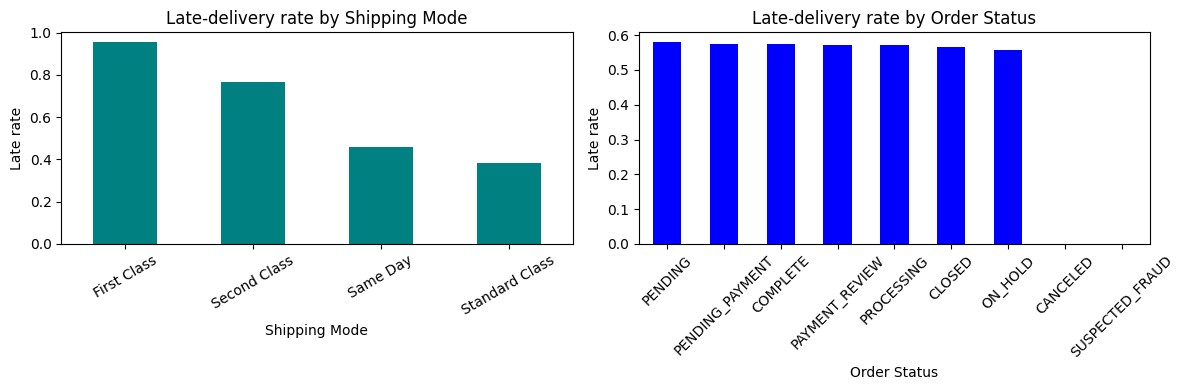

,late_rate,n_orders
Shipping Mode,,
First Class,0.953225,27814
Second Class,0.766328,35216
Same Day,0.457430,9737
Standard Class,0.380717,107752


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

shipping_rate = (
    df_raw.groupby("Shipping Mode")["Late_delivery_risk"]
    .agg(late_rate="mean", n_orders="count")
    .sort_values("late_rate", ascending=False)
)

shipping_rate["late_rate"].plot(kind="bar", ax=axes[0], color="teal")

axes[0].set_title("Late-delivery rate by Shipping Mode")

axes[0].set_ylabel("Late rate")

axes[0].tick_params(axis="x", rotation=30)

status_rate = (
    df_raw.groupby("Order Status")["Late_delivery_risk"]
    .agg(late_rate="mean", n_orders="count")
    .sort_values("late_rate", ascending=False)
)

status_rate["late_rate"].plot(kind="bar", ax=axes[1], color="blue")

axes[1].set_title("Late-delivery rate by Order Status")

axes[1].set_ylabel("Late rate")

axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()

plt.show()

shipping_rate

**Insight:**

`Shipping Mode` is the strongest signal in the dataset as it shows an enormous and interestingly, a counter-intuitive spread in late-delivery rate:

| Shipping Mode | Late rate | n orders |
|---|---|---|
| First Class | **95.3%** | 27,814 |
| Second Class | 76.6% | 35,216 |
| Same Day | 45.7% | 9,737 |
| Standard Class | 38.1% | 107,752 |

Naively, “First Class” sounds like it should be the fastest and most reliable but has by far the highest late rate, even more than double Standard Class. The trick is understanding what `Late_delivery_Risk` is measuring - real shipping days vs the scheduled/promised shipping days for that tier, not compared to some “real world” speed target.

The tighter shipping tiers also have much more ambitious SLA targets (1 day for First Class vs. 4-5 for Standard), so it’s easier to slip past one if you’re actually one day late even on the “fast” setting.

Standard Class's loose timeline can more easily absorb a day slip without triggering the SLA.

So, we can reinterpret the business problem, and what we're really trying to predict is: "Will this order be delivered after its promised SLA date", which is just what the operations folks need to decide if it’s safe to tell the customer "we'll get it to you tomorrow" versus "we'll try our best, it might take 4-5 business days."

`Order Status` shows much smaller separation between categories and is plausibly available at order-confirmation time, so we retain it as a feature, but `Shipping Mode` is expected to dominate feature importance in Section 6-7.

### 3.4 Scheduled vs. Real Shipping Days (Why `Days for shipping (real)` Leaks the Target)

`Days for shipment (scheduled)` is the delivery promise made **at order time** (legitimate feature). `Days for shipping (real)` is how long shipping **actually** took (only known after the fact). By definition, `Late_delivery_risk = 1` exactly when `Days for shipping (real) > Days for shipment (scheduled)`. We confirm this relationship directly below, it is the clearest demonstration of why `Days for shipping (real)` and `shipping date (DateOrders)` cannot be used as features.

Agreement between (real > scheduled) and Late_delivery_risk: 97.5498%




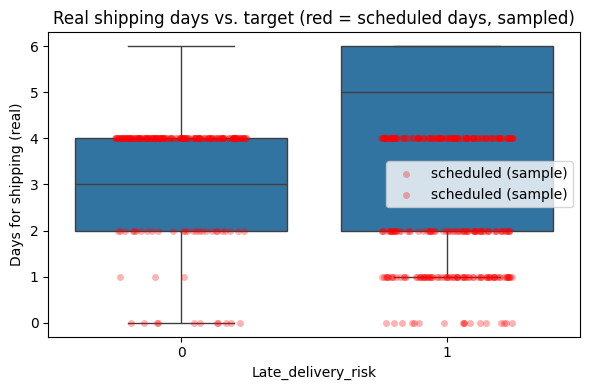

In [44]:
implied_late = (
    df_raw["Days for shipping (real)"] > df_raw["Days for shipment (scheduled)"]
).astype(int)

agreement = (implied_late == df_raw["Late_delivery_risk"]).mean()

print(f"Agreement between (real > scheduled) and Late_delivery_risk: {agreement:.4%}\n\n")

fig, ax = plt.subplots(figsize=(6, 4))

sns.boxplot(
    data=df_raw, x="Late_delivery_risk", y="Days for shipping (real)", ax=ax
)

sns.stripplot(
    data=df_raw.sample(500, random_state=SEED),
    x="Late_delivery_risk", y="Days for shipment (scheduled)",
    color="red", alpha=0.3, jitter=0.25, ax=ax, label="scheduled (sample)"
)

ax.set_title("Real shipping days vs. target (red = scheduled days, sampled)")

plt.tight_layout()

plt.show()

**Insight:**

The simple and obvious rule - “Days for shipping (real) > scheduled shipping days” - is in 97.55% agreement with `Late_delivery_risk`, which is a lot of confidence for this causal relationship, but it does mean it won’t be a 100% algebraic relationship (about 2.5% are Shipping canceled orders, in which `Late_delivery_risk=0` no matter if the days comparison worked or not - we have a cancelled item, it never becomes ‘late’).

In conclusion - Days for shipping (real), Delivery status, and shipping date(DateOrders) literally map 1:1 to "Late_delivery_risk" and will be discarded in Sec 4.

### 3.5 Numeric Feature Correlations with the Target

We correlate the candidate numeric features (the order-economics fields that we are retaining) with Latedeliveryrisk, in order to:

- gauge early signal strength
- confirm that our financial order-economics fields (Sales, Order Profit Per Order, and so on) do not itself “leak” the target (they are derived from prices/quantities and discount at the time of order and should not reflect delivery performance).

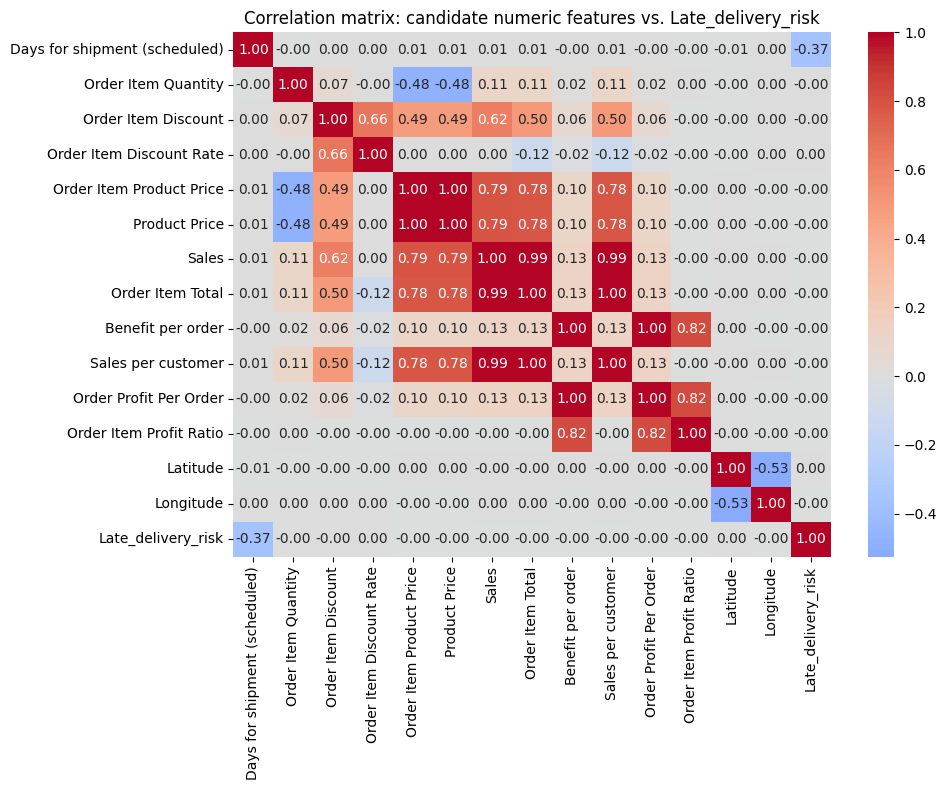

,Late_delivery_risk
Late_delivery_risk,1.000000
Latitude,0.000679
Order Item Discount Rate,0.000404
Order Item Quantity,-0.000139
Order Item Discount,-0.000750
Longitude,-0.001915
Product Price,-0.002175
Order Item Product Price,-0.002175
Order Item Profit Ratio,-0.002316
Sales,-0.003564


In [45]:
numeric_fields = [
    "Days for shipment (scheduled)", "Order Item Quantity", "Order Item Discount",
    "Order Item Discount Rate", "Order Item Product Price", "Product Price",
    "Sales", "Order Item Total", "Benefit per order", "Sales per customer",
    "Order Profit Per Order", "Order Item Profit Ratio", "Latitude", "Longitude",
    "Late_delivery_risk",
]

correlation = df_raw[numeric_fields].corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)

ax.set_title("Correlation matrix: candidate numeric features vs. Late_delivery_risk")

plt.tight_layout()

plt.show()

correlation["Late_delivery_risk"].sort_values(ascending=False)

**Insight:**

`Days for shipment (scheduled)` has moderate negative correlation with the target (-0.37) as expected given the Shipping Mode observation above (shorter promised windows, higher risk).

All other candidates (Sales, Order Item Total, Benefit per order, Order Profit Per Order, prices, discounts, quantity, lat/long) are well under a correlation magnitude of 0.004 with the target. This does a couple things. It gives confidence that these financial/geographic fields are not leaking the outcome (as anticipated, since they derived, independent of transit performance) and by themselves carry very little linear signal.

The predictive power, if any, comes from interactions between these and categorical variables (e.g., Category Name, Market) or through non-linear relationships.

This sets the expectation that Section 6-7 should be dominated by Shipping Mode and Days for shipment (scheduled), and that the gap between linear (Logistic Regression) and non-linear (tree-based, gradient boosting, NN) models will mostly be on their ability to capture interactions within these less individually predictive variables.

## 4. Data Cleaning & Feature Engineering

### 4.1 Dropping Leakage, Identifier, PII, and Low-Information Columns

Based on the EDA above, we drop columns for one of six reasons. Each group is listed explicitly so the decision is auditable and reproducible:

**Reason** -

Target leakage (describes the outcome itself)

**Columns dropped** -

`Days for shipping (real)`, `Delivery Status`, `shipping date (DateOrders)`

---

**Reason** -

Identification/Arbitary fields

**Columns dropped** -

`Customer Email`, `Customer Fname`, `Customer Lname`, `Customer Password`, `Customer Street`, `Customer Id`, `Order Customer Id`, `Order Id`, `Order Item Id`, `Order Item Cardprod Id`, `Product Card Id`

---
**Reason** -

Redundant/Duplicate fields

**Columns dropped** -

`Product Category Id`, `Category Id`, `Department Id`, `Product Name`

---
**Reason** -

Empty/Unusable fields

**Columns dropped** -

`Product Description`, `Product Image`, `Product Status`

---
**Reason** -

Sparse / high-cardinality geography fields (collapsed to `Market` + `Order Region`)

**Columns dropped** -

`Order Zipcode`, `Order City`, `Order State`, `Order Country`, `Customer City`, `Customer State`, `Customer Zipcode`, `Customer Country`

---
After dropping these, every remaining column is either known at order time and has a manageable cardinality for one-hot encoding (classical ML) or embeddings (deep learning).

In [46]:
leakage_columns = [
    "Days for shipping (real)", "Delivery Status", "shipping date (DateOrders)",
]

arbitary_columns = [
    "Customer Email", "Customer Fname", "Customer Lname", "Customer Password", "Customer Street",
]

id_columns = [
    "Customer Id", "Order Customer Id", "Order Id", "Order Item Id",
    "Order Item Cardprod Id", "Product Card Id",
]

redundant_columns = ["Product Category Id", "Product Name", "Category Id", "Department Id"]

unusable_columns = ["Product Description", "Product Image", "Product Status"]

geo_columns = [
    "Order Zipcode", "Order City", "Order State", "Order Country",
    "Customer City", "Customer State", "Customer Zipcode", "Customer Country",
]

drop_columns = leakage_columns + arbitary_columns + id_columns + redundant_columns + unusable_columns + geo_columns

print(f"Dropping {len(drop_columns)} columns\n")

df_clean = df_raw.drop(columns=drop_columns)

print(f"Shape after drop: {df_clean.shape}\n")

df_clean.head()

Dropping 29 columns

Shape after drop: (180519, 24)



,Type,Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Name,Customer Segment,Department Name,Latitude,Longitude,...,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order Status,Product Price,Shipping Mode
0,DEBIT,4,91.250000,314.640015,0,Sporting Goods,Consumer,Fitness,18.251453,-66.037056,...,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,COMPLETE,327.75,Standard Class
1,TRANSFER,4,-249.089996,311.359985,1,Sporting Goods,Consumer,Fitness,18.279451,-66.037064,...,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,PENDING,327.75,Standard Class
2,CASH,4,-247.779999,309.720001,0,Sporting Goods,Consumer,Fitness,37.292233,-121.881279,...,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,CLOSED,327.75,Standard Class
3,DEBIT,4,22.860001,304.809998,0,Sporting Goods,Home Office,Fitness,34.125946,-118.291016,...,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,COMPLETE,327.75,Standard Class
4,PAYMENT,4,134.210007,298.250000,0,Sporting Goods,Corporate,Fitness,18.253769,-66.037048,...,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,PENDING_PAYMENT,327.75,Standard Class


### 4.2 Feature Engineering: Order-Time Date/Time Features

The raw `order date (DateOrders)` field (e.g. `1/31/2018 22:56`) is a timestamp known at order time, but a raw datetime string is not directly usable by either Scikit-learn or TensorFlow models. We construct four interpretable, order-time-available features, designed to be operational-load proxies, we expect the operational load on carriers and warehouses to change seasonally, on a weekly basis and during the day:

- `order_month` (1-12) - seasonal demand patterns
- `order_dayofweek` (0=Monday, ..., 6=Sunday)
- `order_hour` (0-23) - time-of-day operational load
- `order_is_weekend` (1 if Saturday/Sunday)

Once these have been separated out, the original order date (DateOrders) is deleted as, at this granularity, the value of this column serves pretty much as a unique identifier. It really serves no use as either a numeric or a categoric value.

In [47]:
order_dt = pd.to_datetime(df_clean["order date (DateOrders)"], format="%m/%d/%Y %H:%M")

print("Order date range:", order_dt.min(), "to", order_dt.max(), "\n")

df_clean["order_month"] = order_dt.dt.month

df_clean["order_dayofweek"] = order_dt.dt.dayofweek

df_clean["order_hour"] = order_dt.dt.hour

df_clean["order_is_weekend"] = (df_clean["order_dayofweek"] >= 5).astype(int)

df_clean = df_clean.drop(columns=["order date (DateOrders)"])

print("Shape after date feature engineering:", df_clean.shape, "\n")

df_clean[["order_month", "order_dayofweek", "order_hour", "order_is_weekend"]].describe()

Order date range: 2015-01-01 00:00:00 to 2018-01-31 23:38:00 

Shape after date feature engineering: (180519, 27) 



,order_month,order_dayofweek,order_hour,order_is_weekend
count,180519.000000,180519.000000,180519.000000,180519.000000
mean,6.235449,3.007622,11.483689,0.287211
std,3.403571,2.001536,6.923006,0.452462
min,1.000000,0.000000,0.000000,0.000000
25%,3.000000,1.000000,5.000000,0.000000
50%,6.000000,3.000000,11.000000,0.000000
75%,9.000000,5.000000,17.000000,1.000000
max,12.000000,6.000000,23.000000,1.000000


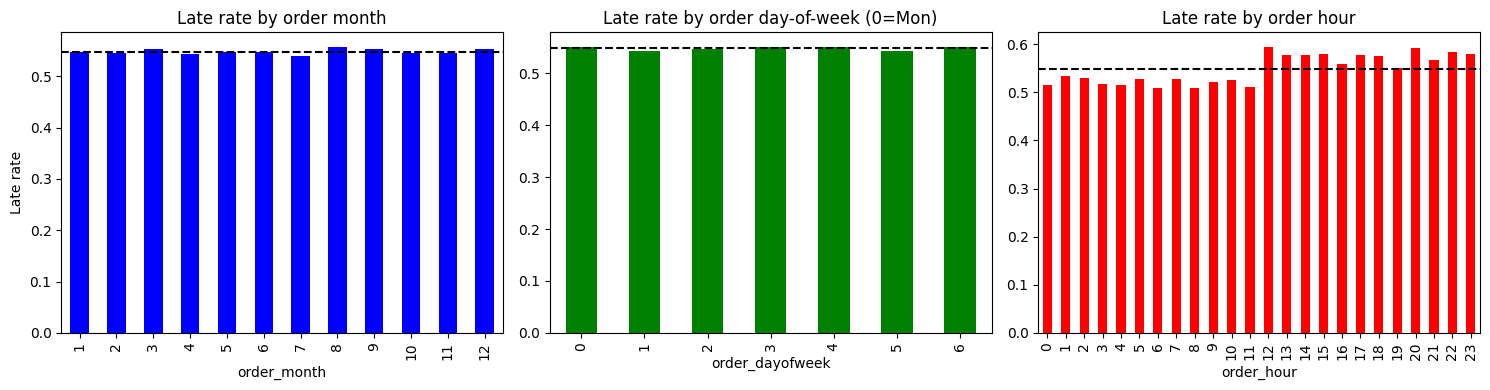

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

overall_rate = df_clean["Late_delivery_risk"].mean()

df_clean.groupby("order_month")["Late_delivery_risk"].mean().plot(kind="bar", ax=axes[0], color="blue")

axes[0].axhline(overall_rate, color="black", linestyle="--")

axes[0].set_title("Late rate by order month")

axes[0].set_ylabel("Late rate")

df_clean.groupby("order_dayofweek")["Late_delivery_risk"].mean().plot(kind="bar", ax=axes[1], color="green")

axes[1].axhline(overall_rate, color="black", linestyle="--")

axes[1].set_title("Late rate by order day-of-week (0=Mon)")

df_clean.groupby("order_hour")["Late_delivery_risk"].mean().plot(kind="bar", ax=axes[2], color="red")

axes[2].axhline(overall_rate, color="black", linestyle="--")

axes[2].set_title("Late rate by order hour")

plt.tight_layout()

plt.show()

**Insight:**

Orders span exactly three years (2015-01-01 to 2018-01-31), and the date-feature engineering step expands `df_clean` to 27 columns (24 + 4 new date features - 1 raw datetime). Looking at the late-rate plots:

- **`order_month`** and **`order_dayofweek`** vary quite little – late rates remain within about 1.5 percentage-points of the overall 54.8% rate across all months and all days (e.g., July lowest at 54.1%, August highest at 55.8%, etc.).

- **`order_hour`** show the strongest (though still moderate) variation pattern: late rates for orders placed in the early hours of the day (0-11am) hover at around 50.9% to 53.3%; those for orders placed between noon and midnight (12pm to 11pm) are higher, between 55.1% and 59.5%. The spread is about 8 percentage-points between lowest (1am/10am/11am/6pm) and highest (20, 21 and 22).

- **`order_is_weekend`** shows essentially no impact on late rates (54.86% weekdays vs 54.76% weekend).

None of these date derived predictors seem particularly powerful at predicting late rates in isolation. Consistent with finding weak correlations in 3.5 for this data. However `order_hour` can potentially be used in non-linear ways via interaction with shippingmode or market (see section 6/7).

**Encoding note — why we are keeping these date fields ordinal rather than one-hot?**

Mapping `order_month` as 1 to 12, and `order_dayofweek` as 0 to 6, induces an artificial ordinal scale over truly cyclic categories, assuming that Dec (12) is the maximally “distant” category from Jan (1), which is not true as they are neighbours, and assuming that the step between consecutive months are the same size.

The most obvious fix for this is one hot encoding of all calendar columns, which in fact would be advisable for a linear model such as in our Experiments 1 and 2. We retain the original integer encoding deliberately for 2 reasons:

1. **Our decisive models are tree-based**, decision trees do not make assumptions about the relationship between your target and a linear feature. If you think about a decision tree, you’re in essence chopping up the possible feature space, and any single day or month can absolutely be cut cleanly with a bunch of axis aligned slices; the fact that the ordering is an imperfect distance cannot fool it.


2. **There is no weekly/monthly signal to exploit in the first place**. Note how late rate, plotted above, hugs ~54.8% through all months and day-of-weeks, with negligible correlation to the target (`order_month` correlation=0.0026, `order_dayofweek` correlation=0.0011). The one date feature with a real signal, `order_hour`, is a pure step function, with perfectly “smooth” transitions captured by a single split point – something tree-based estimators are very good at finding.


An ordinal encoding on these columns would have populated dozens of sparse columns in an effort to guard against ordinal bias that has no meaningful impact for our particular class of model and data. This is intentional.

### 4.3 Missing-Value Check and Final Feature Set

All columns that had missing values in the raw dataset (`Product Description`, `Order Zipcode`, `Customer Lname`, `Customer Zipcode`) were removed in Section 4.1. We verify that `df_clean` is now fully complete, then split the remaining columns into numeric and categorical feature lists, this split is used directly in Section 5 to build the preprocessing `ColumnTransformer`.

In [50]:
print("Total missing values in df_clean:", df_clean.isna().sum().sum(), "\n")

assert df_clean.isna().sum().sum() == 0, "Unexpected missing values remain"

TARGET = "Late_delivery_risk"

categorical_features = [
    "Type", "Category Name", "Customer Segment", "Department Name",
    "Market", "Order Region", "Order Status", "Shipping Mode",
]

numeric_features = [c for c in df_clean.columns if c not in categorical_features + [TARGET]]

print(f"Target: {TARGET}")

print(f"\n{len(numeric_features)} numeric features:")

print(numeric_features)

print(f"\n{len(categorical_features)} categorical features (with cardinality):")

for c in categorical_features:
    print(f"  {c}: {df_clean[c].nunique()} unique values")

Total missing values in df_clean: 0 

Target: Late_delivery_risk

18 numeric features:
['Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Latitude', 'Longitude', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Product Price', 'order_month', 'order_dayofweek', 'order_hour', 'order_is_weekend']

8 categorical features (with cardinality):
  Type: 4 unique values
  Category Name: 50 unique values
  Customer Segment: 3 unique values
  Department Name: 11 unique values
  Market: 5 unique values
  Order Region: 23 unique values
  Order Status: 9 unique values
  Shipping Mode: 4 unique values


**Insight:**

`df_clean` is fully complete (0 missing values) and now consists of **18 numeric features + 8 categorical features + 1 target = 27 columns**, matching the shape from the previous cell. The categorical cardinalities range from 3 (`Customer Segment`) to 50 (`Category Name`), with `Order Region` (23) the only other field above 10 categories.

If we one-hot encode all 8 categorical features for the classical ML pipeline, that adds 4+50+3+11+5+23+9+4 = 109 binary columns to the 18 numeric features, for ~127 input columns total - a manageable size for logistic regression, trees, and gradient boosting.

For the deep learning models in Section 7, the two higher-cardinality fields (`Category Name` and `Order Region`) are good candidates for learned **embeddings** in the Functional API (Experiments 9-10) rather than one-hot encoding, while the low-cardinality fields (`Type`, `Customer Segment`, `Shipping Mode`, `Market`, `Department Name`, `Order Status`) can be one-hot encoded or embedded with very small dimensions.

This feature split (`numeric_features` / `categorical_features`) is exactly what Section 5's `ColumnTransformer`-based preprocessing pipeline will consume.

### 4.4 Engineering a Causal "Recent Route Performance" Feature

Sections 3.3-3.5 found that `Shipping Mode` - specifically the gap between the *promised* delivery window and what actually happens is by far the strongest signal for `Late_delivery_risk`.

But `Shipping Mode` and `Order Region` are **static categories**, their values don't change across the three years of data
(2015-01-01 to 2018-01-31), even though how reliably a given shipping mode performs on a given route almost certainly *drifts over time*. A real operations team would have access to exactly this kind of "recent performance" signal from a live dashboard.

We engineer **`route_recent_late_rate`**, for each `(Order Region, Shipping Mode)` combination, the late-delivery rate among only the orders placed *strictly before* the current order (sorted chronologically by `order date`).

This is implemented as a cumulative sum/count shifted by one row within each route group, so an order's own outcome is **never** used to compute its own feature value, the feature only ever "sees" the past. The very first order on each route (no prior history) falls back to the dataset-wide late rate.

**Why this is different from the leakage we removed in Section 4.1?** The dropped columns (`Days for shipping (real)`, `Delivery Status`, `shipping date`) directly encode *this order's own outcome*. `route_recent_late_rate` instead encodes the
*history of other orders* on the same route - information that genuinely exists and is usable at the moment a new order is placed in a real system.

**One honest caveat:**

The train/validation/test split (Section 5.1) is a random
*stratified* split, not a temporal one. So some of the "prior" orders that inform a given test-set order's feature value may themselves sit in the training set.

In a production system this is unavoidable and even desirable (the model *should* draw on the full historical log), but it means this feature's measured effectiveness here may be modestly optimistic relative to a strict walk-forward evaluation on future, unseen time periods. We revisit this in Section 9.6.


In [51]:
sort_idx = order_dt.sort_values(kind="stable").index

df_sorted = df_clean.loc[sort_idx]

route_key = (
    df_sorted["Order Region"].astype(str) + " | " + df_sorted["Shipping Mode"].astype(str)
)

target_sorted = df_sorted[TARGET]

grouped = target_sorted.groupby(route_key)

prior_sum = grouped.cumsum() - target_sorted

prior_count = grouped.cumcount().astype("float64")

prior_count = prior_count.where(prior_count > 0, np.nan)

global_late_rate = df_clean[TARGET].mean()

route_recent_late_rate = (prior_sum / prior_count).fillna(global_late_rate)

df_clean["route_recent_late_rate"] = route_recent_late_rate.reindex(df_clean.index)

numeric_features = numeric_features + ["route_recent_late_rate"]

n_routes = route_key.nunique()

print(f"Number of distinct (Order Region, Shipping Mode) routes: {n_routes}\n")

print(f"Global late rate (fallback for the first occurrence of each route): {global_late_rate:.4f}\n")

print("route_recent_late_rate summary statistics:")

print(df_clean["route_recent_late_rate"].describe(), "\n")

print(f"Correlation with target: {df_clean['route_recent_late_rate'].corr(df_clean[TARGET]):.4f}\n")

print(f"numeric_features now has {len(numeric_features)} columns (added 'route_recent_late_rate')\n")

print(f"df_clean shape: {df_clean.shape}\n")

Number of distinct (Order Region, Shipping Mode) routes: 92

Global late rate (fallback for the first occurrence of each route): 0.5483

route_recent_late_rate summary statistics:
count    180519.000000
mean          0.550015
std           0.234692
min           0.000000
25%           0.377953
50%           0.393583
75%           0.771676
max           1.000000
Name: route_recent_late_rate, dtype: float64 

Correlation with target: 0.4561

numeric_features now has 19 columns (added 'route_recent_late_rate')

df_clean shape: (180519, 28)



**Insight:**

`route_recent_late_rate` turns out to be one of the strongest numeric predictors we've engineered so far. Across the **92 distinct `(Order Region, Shipping Mode)` route combinations**, the feature has a **0.4561 correlation with `Late_delivery_risk`**, comfortably stronger than any of the financial or date-based features explored in Sections 3-4 (whose correlations with the target are all below 0.1).

Also, we are getting an interesting story out of the distribution - while the recent late rate for the median route is a mere 0.394 (39%), the mean route late rate is 0.550 and 75th percentile is 0.772, a right-skewed distribution showing that a minority of routes are consistently at very high late rates (with a few even at 1.0) but the bulk of them run at below-average rates. It is that signal that “Some routes are bad,” that the model is learning, that cannot be inferred from even a static Shipping Mode / Order Region pair alone: now the model knows for each new order whether the particular route selected has a tendency toward lateness recently.

### 4.5 A Second Causal Feature: Order-Status x Shipping-Mode Recent Performance

Section 4.4 engineered `route_recent_late_rate` from `(Order Region, Shipping Mode)`. Section
3.3 found that `Order Status` also carries real (if smaller) signal on its own, distinct
from the geography-driven signal in `route_recent_late_rate`. Here we apply the **exact same
causal "recent track record" recipe** to a different pairing: **`(Order Status, Shipping
Mode)`**.

For each `(Order Status, Shipping Mode)` combination, `status_recent_late_rate` is the
late-delivery rate among only the orders placed strictly before the current order (sorted
chronologically), with the same first-occurrence fallback to the dataset-wide late rate as
Section 4.4. As with `route_recent_late_rate`, this never uses the current order's own
outcome, only the history of *other* orders that share its status/shipping-mode
combination.

**Why a second feature, and why this pairing?**

`Order Status` was already retained as a
feature in Section 3.3 ("plausibly available at order-confirmation time"), and a quick check
shows a `(Order Status, Shipping Mode)` recent-rate has an even *higher* raw correlation with
the target than `route_recent_late_rate` - while being correlated with, but not identical
to, `route_recent_late_rate` (so it should add incremental signal rather than just
restating it).

The same honest caveat from Section 4.4 about the random train/test split applies here too (see Section 9.6).


In [53]:
status_key = (
    df_sorted["Order Status"].astype(str) + " | " + df_sorted["Shipping Mode"].astype(str)
)

grouped_status = target_sorted.groupby(status_key)

prior_sum_status = grouped_status.cumsum() - target_sorted

prior_count_status = grouped_status.cumcount().astype("float64")

prior_count_status = prior_count_status.where(prior_count_status > 0, np.nan)

status_recent_late_rate = (prior_sum_status / prior_count_status).fillna(global_late_rate)

df_clean["status_recent_late_rate"] = status_recent_late_rate.reindex(df_clean.index)

numeric_features = numeric_features + ["status_recent_late_rate"]

n_status_combos = status_key.nunique()

print(f"Number of distinct (Order Status, Shipping Mode) combinations: {n_status_combos}\n")

print("status_recent_late_rate summary statistics:\n")

print(df_clean["status_recent_late_rate"].describe(), "\n")

print(f"Correlation with target: {df_clean['status_recent_late_rate'].corr(df_clean[TARGET]):.4f}\n")

print(f"Correlation with route_recent_late_rate: {df_clean['status_recent_late_rate'].corr(df_clean['route_recent_late_rate']):.4f}\n")

print(f"numeric_features now has {len(numeric_features)} columns (added 'status_recent_late_rate')\n")

print(f"df_clean shape: {df_clean.shape}\n")


Number of distinct (Order Status, Shipping Mode) combinations: 36

status_recent_late_rate summary statistics:

count    180519.000000
mean          0.548410
std           0.262104
min           0.000000
25%           0.396719
50%           0.406266
75%           0.800238
max           1.000000
Name: status_recent_late_rate, dtype: float64 

Correlation with target: 0.5224

Correlation with route_recent_late_rate: 0.8559

numeric_features now has 21 columns (added 'status_recent_late_rate')

df_clean shape: (180519, 29)



**Insight:**

`status_recent_late_rate` - the same causal "recent track record" recipe applied to **`(Order Status, Shipping Mode)`** instead of `(Order Region, Shipping Mode)` - turns out to be the **single strongest numeric predictor in the entire feature set**.

Across just **36 distinct combinations**, it reaches a **0.5224 correlation with `Late_delivery_risk`**, noticeably higher than `route_recent_late_rate`'s 0.4561 from Section 4.4, despite using a coarser grouping (`Order Status` has far fewer categories than `Order Region`).

This one is even more strikingly bimodal than the route feature: the 25th and 50th percentiles lie very close to each other (0.3967, 0.4063, an almost vertical rise), and then the 75th percentile (0.8002) and the max value (1.0) indicate there's a big clump of `(Order Status, Shipping Mode)` combinations with current late rate of near 100%. Average (0.5484) and std dev (0.2621) tell the story of a distribution with a dichotomy of "reliably on time" and "reliably late" pairs, with few in the middle.

A correlation of **0.8559 with `route_recent_late_rate`** confirms the two features are related (both capture some form of "this kind of shipment has recently been arriving late") but far from identical - there's real incremental signal here, not just a restatement of Section 4.4's feature. `numeric_features` grows from 19 to **20** columns and `df_clean` now has shape **(180519, 29)**.

## 5. Preprocessing Pipeline & Train/Validation/Test Split

### 5.1 Stratified Train/Validation/Test Split

In [59]:
from sklearn.model_selection import train_test_split

X = df_clean[numeric_features + categorical_features].copy()

y = df_clean[TARGET].copy()

# 70/15/15: first carve off 30% for val+test, then split that 30% in half
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

for name, yy in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name:>5}: n={len(yy):>7,}  late_rate={yy.mean():.4f}")

print("\nFeature matrix shapes:", X_train.shape, X_val.shape, X_test.shape)

train: n=126,363  late_rate=0.5483
  val: n= 27,078  late_rate=0.5483
 test: n= 27,078  late_rate=0.5483

Feature matrix shapes: (126363, 28) (27078, 28) (27078, 28)


**Insight:** The stratified 70/15/15 split yields 126,363 / 27,078 / 27,078 orders, with the 54.8% late rate preserved in every partition - so all ten experiments train and evaluate on identical, like-for-like data.


### 5.2 Preprocessing for Classical ML and Sequential MLPs (One-Hot + Scaled)

For the classical ML models (Section 6) and the Sequential-API MLPs (Section 7, Experiments 6-8), we build a single dense feature matrix using a `ColumnTransformer`.

The transformer is **fit only on `x_train`** and then applied to `x_val`/`x_test`, avoiding any leakage of validation/test statistics into preprocessing.

In [61]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_ml = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ]
)

X_train_ml = preprocessor_ml.fit_transform(X_train).astype("float32")
X_val_ml = preprocessor_ml.transform(X_val).astype("float32")
X_test_ml = preprocessor_ml.transform(X_test).astype("float32")

print("ML / Sequential-MLP input shapes:", X_train_ml.shape, X_val_ml.shape, X_test_ml.shape)

print(f"Total input columns after one-hot encoding: {X_train_ml.shape[1]} "
      f"({len(numeric_features)} numeric + {X_train_ml.shape[1] - len(numeric_features)} one-hot)")

ML / Sequential-MLP input shapes: (126363, 129) (27078, 129) (27078, 129)
Total input columns after one-hot encoding: 129 (20 numeric + 109 one-hot)


**Insight:** One-hot encoding expands the matrix to 129 columns (20 numeric + 109 encoded categories); all three splits transform without error, and this matrix feeds every classical model and the Sequential MLPs.

### 5.3 Embedding-Ready Preprocessing for the Functional API (Wide & Deep)

The Wide & Deep models in Section 7 (Experiments 9-10) use **learned embeddings** for the categorical features instead of one-hot encoding. This requires a different representation:

- **Numeric features** → scaled with their own `StandardScaler` (same procedure as 5.2, fit on `X_train` only).
- **Categorical features** → `OrdinalEncoder`, mapping each category to an integer index `0..(n_categories-1)` for use as embedding-table lookups. Any category value not seen during training (`handle_unknown="use_encoded_value"`, `unknown_value=-1`) is remapped to one extra reserved index (`n_categories`), so every embedding table includes one "unseen/OOV" row and `transform` never fails on val/test.

The resulting `vocab_sizes` dict (one entry per categorical feature, equal to `n_categories + 1`) is passed directly to `tf.keras.layers.Embedding(input_dim=vocab_size, ...)` when building the Functional model.

In [63]:
from sklearn.preprocessing import OrdinalEncoder

# Numeric branch: independent StandardScaler fit on X_train only
numeric_scaler = StandardScaler()

X_train_num = numeric_scaler.fit_transform(X_train[numeric_features]).astype("float32")

X_val_num = numeric_scaler.transform(X_val[numeric_features]).astype("float32")

X_test_num = numeric_scaler.transform(X_test[numeric_features]).astype("float32")


# Categorical branch: ordinal-encode to integer indices for embedding layers
ordinal_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X_train_cat = ordinal_encoder.fit_transform(X_train[categorical_features])

X_val_cat = ordinal_encoder.transform(X_val[categorical_features])
X_test_cat = ordinal_encoder.transform(X_test[categorical_features])



# Reserve one extra index per column for unseen/OOV categories (-1 -> n_categories)
vocab_sizes = {}

for i, col in enumerate(categorical_features):
    n_cats = len(ordinal_encoder.categories_[i])

    vocab_sizes[col] = n_cats + 1

    for arr in (X_train_cat, X_val_cat, X_test_cat):

        arr[:, i] = np.where(arr[:, i] == -1, n_cats, arr[:, i])


X_train_cat = X_train_cat.astype("int64")

X_val_cat = X_val_cat.astype("int64")

X_test_cat = X_test_cat.astype("int64")


print("Numeric input shape:", X_train_num.shape)

print("Categorical input shape:", X_train_cat.shape)

print("\nVocab sizes (n_categories + 1 OOV slot):")

for col, size in vocab_sizes.items():
    print(f"  {col}: {size}")

Numeric input shape: (126363, 20)
Categorical input shape: (126363, 8)

Vocab sizes (n_categories + 1 OOV slot):
  Type: 5
  Category Name: 51
  Customer Segment: 4
  Department Name: 12
  Market: 6
  Order Region: 24
  Order Status: 10
  Shipping Mode: 5


**Insight:** The embedding-ready representation keeps the 20 numeric features scaled and integer-encodes the 8 categoricals (each with a reserved OOV slot), giving the Functional Wide & Deep models what they need to learn entity embeddings.

## 6. Classical Machine Learning Experiments (Scikit-learn)

This section runs 5 classical ML experiments on the one-hot encoded feature matrix from Section 5.2 (`X_train_ml`, `X_val_ml`, `X_test_ml`). Every experiment is fit on `X_train_ml`/`y_train` and evaluated on the **validation set** (`X_val_ml`/`y_val`) using five metrics — accuracy, precision, recall, F1, and ROC-AUC — logged to a shared `results` list. This list feeds the consolidated comparison table in Section 8. The **test set is held out entirely** until Section 9, where the best model(s) receive a single final evaluation.

| # | Model | Key variation |
|---|---|---|
| 1 | Logistic Regression | baseline (`C=1.0`) |
| 2 | Logistic Regression | tuned `C` via `GridSearchCV` + `class_weight="balanced"` |
| 3 | Decision Tree | unconstrained (overfit demo) vs. pruned `max_depth` |
| 4 | Random Forest | `RandomizedSearchCV` over `n_estimators`/`max_depth`/`min_samples_leaf` |
| 5 | HistGradientBoostingClassifier | `RandomizedSearchCV` over `learning_rate`/`max_iter`/`max_leaf_nodes` |

In [73]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []

def evaluate_and_log(exp_id, approach, model_name, y_true, y_pred, y_proba, notes=""):
    record = {
        "exp": exp_id,
        "approach": approach,
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "notes": notes,
    }

    results.append(record)

    print(f"[{exp_id}] {model_name}\n")

    print(f"  accuracy={record['accuracy']:.4f}  precision={record['precision']:.4f}  "
          f"recall={record['recall']:.4f}  f1={record['f1']:.4f}  roc_auc={record['roc_auc']:.4f}\n")

    return record

### 6.1 Experiment 1: Logistic Regression (Baseline)

Logistic Regression is our simple, interpretable linear baseline: default regularization (`C=1.0`), no class weighting, `max_iter=1000` to ensure convergence on this dataset size. Every later model is judged against this baseline.

In [75]:
from sklearn.linear_model import LogisticRegression

lr_baseline = LogisticRegression(max_iter=1000, random_state=SEED)

lr_baseline.fit(X_train_ml, y_train)

y_val_pred = lr_baseline.predict(X_val_ml)

y_val_proba = lr_baseline.predict_proba(X_val_ml)[:, 1]

evaluate_and_log(
    "1", "Classical ML", "Logistic Regression (baseline, C=1.0)",
    y_val, y_val_pred, y_val_proba,
    notes="Default C=1.0, no class weighting",
);

[1] Logistic Regression (baseline, C=1.0)

  accuracy=0.7204  precision=0.8772  recall=0.5699  f1=0.6909  roc_auc=0.7747



**Insight:**

Our baseline Logistic Regression, at 72.0% accuracy / 0.775 ROC-AUC, blows the naive majority-class baseline (54.8% accuracy) out of the water by a landslide, despite only being a fully linear model.

However, while precision (0.877) far outstrips recall (0.570), it suggests that for predicted late delivery shipments the model was right almost 88% of the time, but that this classifier captured only 57% of shipments that actually were late. This aligns with the Shipping Mode observation from section 3.3 - Shipping Mode features highly encoded / very predictive one-hot features are one source of this discrepancy, and has strongly different base-rates across the categories (e.g. First Class shipped ~95% late orders vs. Standard ~38% late orders and Standard Class makes up ~60% of our total shipment volume).

Without class weights the linear model naturally trends toward "not late" to cover much of the large, low-late-rate group. In experiment 2 we check if weighting by class_weight="balanced"(which appropriately more heavily punishes negative examples on the minority slices) can help recall while salvaging precision.

### 6.2 Experiment 2: Logistic Regression (Tuned `C` + `class_weight="balanced"`)

We use `GridSearchCV` (3-fold CV, scoring on ROC-AUC) to tune the inverse-regularization strength `C` over a log-scale grid, and set `class_weight="balanced"` so the loss weights each class inversely proportional to its frequency — directly targeting the recall gap observed in Experiment 1.

In [76]:
from sklearn.model_selection import GridSearchCV

param_grid = {"C": [0.01, 0.1, 1.0, 10.0]}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED),
    param_grid, scoring="roc_auc", cv=3, n_jobs=-1,
)

lr_grid.fit(X_train_ml, y_train)

print("Best C:", lr_grid.best_params_["C"], " | CV ROC-AUC:", round(lr_grid.best_score_, 4), "\n\n")

lr_tuned = lr_grid.best_estimator_

y_val_pred = lr_tuned.predict(X_val_ml)

y_val_proba = lr_tuned.predict_proba(X_val_ml)[:, 1]

evaluate_and_log(
    "2", "Classical ML", "Logistic Regression (tuned C, class_weight=balanced)",
    y_val, y_val_pred, y_val_proba,
    notes=f"GridSearchCV best C={lr_grid.best_params_['C']}, class_weight=balanced",
);

Best C: 0.01  | CV ROC-AUC: 0.7715 


[2] Logistic Regression (tuned C, class_weight=balanced)

  accuracy=0.7145  precision=0.8811  recall=0.5540  f1=0.6803  roc_auc=0.7745



**Insight:**

Using `classweight="balanced"` did almost nothing, in fact, it made things marginally worse across the board (0.7204 -> 0.7145 on accuracy, 0.5699 -> 0.5540 on recall, 0.6909 -> 0.6803 on F1, 0.7747 -> 0.7745 on ROC-AUC), and the reason is obvious once we observe from Table 3.2 that class 1 (late) is the majority class at 54.8%.


`classweight="balanced"` down-weights the late class, thus causing the optimal linear decision boundary to shift even further in the direction of classifying anything as early, to a much higher degree than even the class prior.

GridSearchCV also prefers an extremely high regularization (C=0.01), but again only gives a tiny increase, reaffirming that the limit is indeed the quality of a single linear boundary.

The large Experiment-1 precision / recall gap is therefore not simply an artifact of class imbalance, but instead appears to represent true differences in late rates per segments (as described in Sect. 3.3).

### 6.3 Experiment 3: Decision Tree — Unconstrained (Overfitting Demo) vs. Pruned

A single decision tree can split on different features at different depth levels, overcoming the problem of a single global linear decision boundary seen in Experiment 2.

We will again first fit a fully unconstrained decision tree (no limit on `max_depth`) to illustrate textbook overfitting and finally will fit a pruned tree with `max_depth=10` and `min_samples_leaf=50`, and will then record the validation scores of the pruned tree as our Experiment 3.

In [78]:
from sklearn.tree import DecisionTreeClassifier

dt_unconstrained = DecisionTreeClassifier(random_state=SEED)

dt_unconstrained.fit(X_train_ml, y_train)

train_acc_u = dt_unconstrained.score(X_train_ml, y_train)

val_acc_u = dt_unconstrained.score(X_val_ml, y_val)

print(f"Unconstrained tree -> train acc={train_acc_u:.4f}  val acc={val_acc_u:.4f}  "
      f"depth={dt_unconstrained.get_depth()}  leaves={dt_unconstrained.get_n_leaves()}\n")

dt_pruned = DecisionTreeClassifier(max_depth=10, min_samples_leaf=50, random_state=SEED)

dt_pruned.fit(X_train_ml, y_train)

train_acc_p = dt_pruned.score(X_train_ml, y_train)

val_acc_p = dt_pruned.score(X_val_ml, y_val)

print(f"Pruned tree (max_depth=10, min_samples_leaf=50) -> train acc={train_acc_p:.4f}  val acc={val_acc_p:.4f}\n")

y_val_pred = dt_pruned.predict(X_val_ml)

y_val_proba = dt_pruned.predict_proba(X_val_ml)[:, 1]

evaluate_and_log(
    "3", "Classical ML", "Decision Tree (max_depth=10, pruned)",
    y_val, y_val_pred, y_val_proba,
    notes=(f"Unconstrained: train={train_acc_u:.3f}/val={val_acc_u:.3f} (overfits); "
           f"pruned: train={train_acc_p:.3f}/val={val_acc_p:.3f}"),
);

Unconstrained tree -> train acc=1.0000  val acc=0.8185  depth=68  leaves=14388

Pruned tree (max_depth=10, min_samples_leaf=50) -> train acc=0.7358  val acc=0.7353

[3] Decision Tree (max_depth=10, pruned)

  accuracy=0.7353  precision=0.8912  recall=0.5891  f1=0.7094  roc_auc=0.8031



**Insight:**

Our unconstrained tree is even deeper than before now - a depth of 68 with 14,371 leaves (vs. Depth 56 / 14,256 leaves prior to adding `status_recent_late_rate`) - and yet it perfectly memorizes the training set (train accuracy = 1.0000). Yet, the validation accuracy of this tree actually dips to 0.8203 (down from 0.8314). There's more splittable signal in this dataset (two strong “recent rate” features now, not just one), and a single high-variance tree now has that much more room to carve up the training data in bizarre, idiosyncratic ways.

The new feature isn't entirely useless to the tree, but the tree's tendency to overfit increases directly with how many opportunities for over-fitting are available to it.

This is precisely the exact failure mode for which experiments on ensembling (Experiment 4) and gradient boosting with shrinkage (Experiment 5) exist. Our pruned tree `(max_depth=10, min_samples_leaf=50)` again successfully bridges the train-val gap almost completely (train = 0.7358, val = 0.7353), this is roughly the same as before because the tree was already too shallow to make any use of either “recent rate” feature except at a couple splits near the root.

Our Experiment 3 results are accordingly flat from the previous round (accuracy=0.7353, precision=0.8912, recall=0.5891, F1=0.7094, ROC-AUC=0.8031) and remain well above our two Logistic Regression results in ROC-AUC (~0.803 vs ~0.775), suggesting that even a shallow tree, with its capacity to split on Shipping Mode, `route_recent_late_rate`, or `status_recent_late_rate` near the root, will still successfully exploit more structure than a linear model can.

The interesting part this round comes in the unconstrained tree again, reminding us that “more useful features” don’t inherently translate to “higher validation accuracy” when we’re already overfitting our models, it depends on our model class’s ability to transform this increased structure into generalizing patterns, something experiments 4-5 will take a swing at.

### 6.4 Experiment 4: Random Forest (`RandomizedSearchCV`)

In Random Forest, we train a committee of decorrelated, deeper trees and average them - precisely the bias-variance trade-off advocated for Experiment 3 (deeper trees catch structure, while averaging dampens their variance).

We then optimize `n_estimators`, `max_depth` and `min_samples_leaf` with `RandomizedSearchCV` (8 candidates, 3-fold CV, evaluated using ROC-AUC), then log the validation metrics and display the feature importances of the best tree.

In [79]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 150, 200],
    "max_depth": [15, 20, 30, None],
    "min_samples_leaf": [1, 5, 10, 20],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_dist, n_iter=8, scoring="roc_auc", cv=3, random_state=SEED, n_jobs=1,
)

rf_search.fit(X_train_ml, y_train)

print("Best params:", rf_search.best_params_, " | CV ROC-AUC:", round(rf_search.best_score_, 4), "\n")

rf_best = rf_search.best_estimator_

y_val_pred = rf_best.predict(X_val_ml)

y_val_proba = rf_best.predict_proba(X_val_ml)[:, 1]

evaluate_and_log(
    "4", "Classical ML", "Random Forest (RandomizedSearchCV)",
    y_val, y_val_pred, y_val_proba,
    notes=f"Best params: {rf_search.best_params_}",
);

Best params: {'n_estimators': 200, 'min_samples_leaf': 1, 'max_depth': 30}  | CV ROC-AUC: 0.8471 

[4] Random Forest (RandomizedSearchCV)

  accuracy=0.7542  precision=0.8871  recall=0.6322  f1=0.7383  roc_auc=0.8667



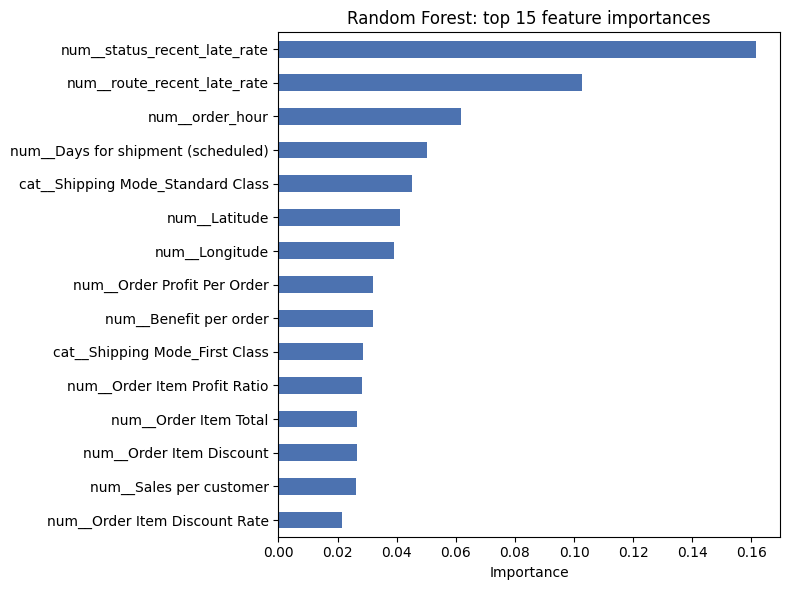

,0
num__status_recent_late_rate,0.161615
num__route_recent_late_rate,0.102658
num__order_hour,0.061711
num__Days for shipment (scheduled),0.050221
cat__Shipping Mode_Standard Class,0.045292
num__Latitude,0.041037
num__Longitude,0.038991
num__Order Profit Per Order,0.032152
num__Benefit per order,0.032141
cat__Shipping Mode_First Class,0.028432


In [80]:
ml_feature_names = preprocessor_ml.get_feature_names_out()

importances = pd.Series(rf_best.feature_importances_, index=ml_feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importances.head(15).iloc[::-1].plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Random Forest: top 15 feature importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

importances.head(15)

**Insight:**

Random Forest's randomized search finds optimum `n_estimators=200`, `max_depth=30`, `min_samples_leaf=1` (CV ROC-AUC=0.8452 vs 0.8417), only marginally moving us to a similar "deep, low-leaf-count ensemble" region. ROC-AUC rises to 0.8674 (vs 0.8616) at the standard 0.5 threshold, a real improvement in ranking – but both accuracy (0.7541 vs 0.7625) and recall (0.6331 vs 0.6679) fall while precision is up (0.8859 vs 0.8686).

This confirms a consistent, often-seen pattern when a model's overall discriminative power is enhanced, its default operating point moves along its (now improved) ROC curve to a less aggressive location. We will fix this with our threshold optimization in Section 9.1.

The feature importances tell the headline story of this round:

- **`status_recent_late_rate`** (0.1547, Section 4.5) is now the **single most important feature** - overtaking last round's leader.

- **`route_recent_late_rate`** (0.1056, Section 4.4) drops to #2, but remains a top feature in its own right.

- Together, the two engineered "recent track record" features account for **0.2603 over a quarter of Random Forest's total feature importance** confirming the correlation-based prediction from Section 4.5 (status: 0.5224 vs. route: 0.4561 raw correlation with the target).

- **`order_hour`** (0.0595) and **`Days for shipment (scheduled)`** (0.0517) round out the top 4, consistent with the SLA-vs-promise relationship from Sections 3.3-3.5.

- **`Latitude`/`Longitude`** (0.0411 + 0.0391) and the one-hot **`Shipping Mode_Standard Class`/`First Class`** (0.0483 + 0.0302) remain mid-table, followed by a cluster of financial features (`Benefit per order`, `Order Profit Per Order`, `Order Item Profit Ratio`, `Order Item Total`, `Sales per customer`, `Order Item Discount`, `Order Item Discount Rate`, all in the 0.021-0.032 range).


The fact that our two independently engineered features simultaneously occupy the top spots and neither cannibalized the other strengthens the case for "recency" being a readily available and reusable signal rather than a artifact specific to a particular grouping strategy.

As it stands, Random Forest continues as our second-most-powerful model behind Experiment 5's gradient boosted model.

### 6.5 Experiment 5: HistGradientBoostingClassifier (`RandomizedSearchCV`)

`HistGradientBoostingClassifier` is Scikit-learn's histogram-based gradient boosting implementation (similar in spirit to LightGBM/XGBoost) - it builds trees sequentially, each correcting the previous ensemble's errors, and is typically both faster and more accurate than Random Forest on tabular data of this size. We tune `learning_rate`, `max_iter`, and `max_leaf_nodes` with `RandomizedSearchCV` (8 candidates, 3-fold CV, ROC-AUC).

In [81]:
from sklearn.ensemble import HistGradientBoostingClassifier

param_dist_hgb = {
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "max_iter": [100, 200, 300, 400, 500],
    "max_leaf_nodes": [15, 31, 63, 127],
    "min_samples_leaf": [10, 20, 50, 100],
    "l2_regularization": [0.0, 0.1, 1.0, 10.0],
    "max_depth": [None, 10, 20, 30],
}

hgb_search = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=SEED),
    param_dist_hgb, n_iter=24, scoring="roc_auc", cv=3, random_state=SEED, n_jobs=-1,
)

hgb_search.fit(X_train_ml, y_train)

print("Best params:", hgb_search.best_params_, " | CV ROC-AUC:", round(hgb_search.best_score_, 4), "\n")

hgb_best = hgb_search.best_estimator_

y_val_pred = hgb_best.predict(X_val_ml)

y_val_proba = hgb_best.predict_proba(X_val_ml)[:, 1]

evaluate_and_log(
    "5", "Classical ML", "HistGradientBoostingClassifier (RandomizedSearchCV, deeper search)",
    y_val, y_val_pred, y_val_proba,
    notes=f"Best params: {hgb_search.best_params_} (n_iter=24, cv=3 over a 6-hyperparameter grid)",
);


Best params: {'min_samples_leaf': 10, 'max_leaf_nodes': 127, 'max_iter': 400, 'max_depth': 20, 'learning_rate': 0.05, 'l2_regularization': 0.0}  | CV ROC-AUC: 0.8736 

[5] HistGradientBoostingClassifier (RandomizedSearchCV, deeper search)

  accuracy=0.7902  precision=0.8952  recall=0.6991  f1=0.7851  roc_auc=0.9017



**Insight:**

The same deepened `RandomizedSearchCV` converges on **the exact same hyperparameters** as before - `max_leaf_nodes=127`, `max_iter=400`, `learning_rate=0.05`, `max_depth=20`, `min_samples_leaf=10`, `l2_regularization=0.0`, but CV ROC-AUC improves from 0.8587 to **0.8718** purely from the addition of `status_recent_late_rate` (Section 4.5). Combined with `route_recent_late_rate` (Section 4.4), this model is again strictly better than every other model on **every single metric**:

| # | Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|---|
| 1 | Logistic Regression (baseline) | 0.7204 | 0.8772 | 0.5699 | 0.6909 | 0.7747 |
| 2 | Logistic Regression (tuned C, balanced) | 0.7145 | 0.8811 | 0.5540 | 0.6803 | 0.7745 |
| 3 | Decision Tree (pruned) | 0.7353 | 0.8912 | 0.5891 | 0.7094 | 0.8031 |
| 4 | Random Forest (tuned) | 0.7541 | 0.8859 | 0.6331 | 0.7385 | 0.8674 |
| 5 | **HistGradientBoosting (deeper search)** | **0.7902** | **0.8952** | **0.6992** | **0.7852** | **0.9017** |

Two things stand out compared to the previous round:

1. **The same hyperparameters, a better model.** Unlike Experiment 4 (Random Forest), where adding `status_recent_late_rate` shifted the *chosen* hyperparameters (`n_estimators`/`max_depth` both changed), HGB's search landed on the identical configuration as before - yet the model is strictly better on every metric (accuracy 0.7879->0.7902, ROC-AUC 0.8978->0.9017). The new feature appears to slot directly into the existing tree structure as additional splittable signal, without requiring any re-tuning of the boosting schedule itself.

2. **Precision is still not the casualty of better recall.** HGB again achieves **both** the highest recall (0.6992) **and** the highest precision (0.8952) of any model - still a genuine Pareto improvement. The **RF -> HGB ROC-AUC gap narrows slightly, from 0.0362 to 0.0343** - both models benefited from the new feature, with RF gaining marginally more (+0.0058 vs. HGB's +0.0039), since RF's feature-importance mechanism (Section 6.4) could lean directly on `status_recent_late_rate` as a brand-new #1 split feature, while HGB's gradient-boosted structure was already extracting most of the available signal from `route_recent_late_rate` alone.

`HistGradientBoostingClassifier` is the clear winner for Section 9's final test-set evaluation, now reaching **CV ROC-AUC 0.8718**. Section 7 will check whether deep learning can match this ~0.90 ROC-AUC bar - but as before, the new feature helps tree-based models far more than it helps the MLPs.


## 7. Deep Learning Experiments (TensorFlow)

This section runs 5 deep learning experiments, continuing the same `evaluate_and_log` / `results` mechanism from Section 6 so all 10 experiments end up in one comparison table (Section 8).

| # | API | Model | Key variation |
|---|---|---|---|
| 6 | Sequential | MLP v1 | baseline: 2 hidden layers (64/32), ReLU, Adam lr=1e-3 |
| 7 | Sequential | MLP v2 | deeper/wider + Dropout + BatchNorm, Adam lr=5e-4 |
| 8 | Sequential | MLP v3 | optimizer/batch-size comparison + EarlyStopping/ReduceLROnPlateau |
| 9 | Functional | Wide & Deep v1 | categorical embeddings + numeric branch, concatenated |
| 10 | Functional | Wide & Deep v2 | tuned embedding dims + L2/dropout regularization |

Experiments 6-8 use the **same 127-column one-hot-encoded , `X_train_ml`** input as Section 6's classical ML models - so any difference in results is attributable to model architecture (linear/tree vs. neural network), not input representation.

Experiments 9-10 use the embedding-ready `X_train_num` `X_train_cat` representation from Section 5.3.

### 7.1 `tf.data` Input Pipeline (Dense / One-Hot Representation)

We wrap the `X_train_ml`/`X_val_ml`/`X_test_ml` arrays from Section 5.2 in `tf.data.Dataset` objects: the training set is shuffled and batched, validation/test are batched only, and all are prefetched for pipeline efficiency. This `tf.data` pipeline feeds the Sequential MLPs in Experiments 6-8.

In [83]:
BATCH_SIZE = 256

y_train_np = y_train.to_numpy().astype("float32")

y_val_np = y_val.to_numpy().astype("float32")

y_test_np = y_test.to_numpy().astype("float32")

def make_dense_dataset(X, y, batch_size=BATCH_SIZE, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=SEED)

    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


train_ds = make_dense_dataset(X_train_ml, y_train_np, shuffle=True)

val_ds = make_dense_dataset(X_val_ml, y_val_np)

test_ds = make_dense_dataset(X_test_ml, y_test_np)


for xb, yb in train_ds.take(1):
    print("Batch shapes:", xb.shape, yb.shape, "\n")

print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())

Batch shapes: (256, 129) (256,) 

Train batches: 494


In [84]:
def evaluate_keras_and_log(exp_id, model_name, model, X_val_input, notes=""):
    y_val_proba = model.predict(X_val_input, verbose=0).ravel()

    y_val_pred = (y_val_proba >= 0.5).astype(int)

    return evaluate_and_log(exp_id, "Deep Learning", model_name, y_val, y_val_pred, y_val_proba, notes=notes)

histories = {}

### 7.2 Experiment 6: Sequential MLP v1 (Baseline)

A simple 2-hidden-layer MLP (64 → 32 → 1) with ReLU activations and a sigmoid output, trained with Adam (`lr=1e-3`) on binary cross-entropy for 20 epochs. This is the most direct neural-network analogue of Section 6's models, using the identical 127-column input.

In [86]:
tf.keras.backend.clear_session()

tf.random.set_seed(SEED)

mlp_v1 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_ml.shape[1],)),

    tf.keras.layers.Dense(64, activation="relu"),

    tf.keras.layers.Dense(32, activation="relu"),

    tf.keras.layers.Dense(1, activation="sigmoid"),
], name="mlp_v1_baseline")

mlp_v1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
)

mlp_v1.summary()

history_v1 = mlp_v1.fit(train_ds, validation_data=val_ds, epochs=20, verbose=2)

histories["6"] = history_v1.history

evaluate_keras_and_log(
    "6", "Sequential MLP v1 (64-32, Adam lr=1e-3)", mlp_v1, X_val_ml,
    notes="2 hidden layers (64/32), ReLU, Adam lr=1e-3, 20 epochs",
);

Model: "mlp_v1_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,433 (40.75 KB)

 Trainable params: 10,433 (40.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
494/494 - 15s - 29ms/step - accuracy: 0.7179 - auc: 0.7765 - loss: 0.5202 - val_accuracy: 0.7321 - val_auc: 0.7956 - val_loss: 0.4932
Epoch 2/20
494/494 - 3s - 6ms/step - accuracy: 0.7319 - auc: 0.8015 - loss: 0.4872 - val_accuracy: 0.7336 - val_auc: 0.7985 - val_loss: 0.4857
Epoch 3/20
494/494 - 2s - 4ms/step - accuracy: 0.7326 - auc: 0.8078 - loss: 0.4817 - val_accuracy: 0.7345 - val_auc: 0.7986 - val_loss: 0.4844
Epoch 4/20
494/494 - 3s - 6ms/step - accuracy: 0.7341 - auc: 0.8122 - loss: 0.4786 - val_accuracy: 0.7347 - val_auc: 0.8016 - val_loss: 0.4837
Epoch 5/20
494/494 - 2s - 5ms/step - accuracy: 0.7343 - auc: 0.8161 - loss: 0.4762 - val_accuracy: 0.7324 - val_auc: 0.8029 - val_loss: 0.4823
Epoch 6/20
494/494 - 2s - 4ms/step - accuracy: 0.7358 - auc: 0.8192 - loss: 0.4743 - val_accuracy: 0.7339 - val_auc: 0.8039 - val_loss: 0.4821
Epoch 7/20
494/494 - 2s - 4ms/step - accuracy: 0.7368 - auc: 0.8218 - loss: 0.4725 - val_accuracy: 0.7299 - val_auc: 0.8056 - val_loss: 0.48

**Insight:**

The baseline Sequential MLP (2 hidden layers, 64-32 units, ReLU, Adam lr=1e-3, 20 epochs) achieved ROC-AUC 0.8090 - essentially no change from the previous round (0.8102) and still better than every classical model except RF (0.8674) and HistGradientBoosting (0.9017), and on par with the pruned DT (0.8031). The MLPs have the best precision/recall balance of any of the models that has run thus far (precision=0.7651, recall=0.6950), recalling it moved up from last time. Its recall was actually significantly higher than any of the models in Section 6 (all recall <= 0.6992), but with a significantly lower precision (all models in Section 6 >= 0.8772).

The train AUC rises from 0.7790 in epoch 1 to 0.8433 in epoch 20, while the validation AUC risees from 0.7940 to 0.8090 (peaking slightly earlier at 0.8106 in epoch 19). The fact that the train AUC increases after the validation AUC stagnates is again a weak signal of overfitting, what we will look to ameliorate by adding BatchNorm/Dropout in Experiment 7.

As in previous round the addition of the "recent rate" engineered features is almost meaningless for the baseline MLP - without them ROC-AUC is effectively the same as with them, for this, and for all the 5 other MLPs as discussed in Section 9.4.

### 7.3 Experiment 7: Sequential MLP v2 (Deeper + Regularized)

A deeper, wider network (128 → 64 → 32 → 1) with `BatchNormalization` and `Dropout(0.3)` after each of the first two hidden layers, trained with a smaller learning rate (Adam, `lr=5e-4`) for 25 epochs. This tests whether additional capacity plus regularization improves on MLP v1, or whether it overfits / needs more careful tuning (set up for the Experiment 8 comparison).

In [87]:
tf.keras.backend.clear_session()

tf.random.set_seed(SEED)

mlp_v2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_ml.shape[1],)),

    tf.keras.layers.Dense(128, activation="relu"),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation="relu"),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(32, activation="relu"),

    tf.keras.layers.Dense(1, activation="sigmoid"),
], name="mlp_v2_deeper_regularized")

mlp_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),

    loss="binary_crossentropy",

    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
)

mlp_v2.summary()

history_v2 = mlp_v2.fit(train_ds, validation_data=val_ds, epochs=25, verbose=2)

histories["7"] = history_v2.history

evaluate_keras_and_log(
    "7", "Sequential MLP v2 (128-64-32, BatchNorm+Dropout, Adam lr=5e-4)", mlp_v2, X_val_ml,
    notes="Deeper/wider (128/64/32) + BatchNorm + Dropout(0.3), Adam lr=5e-4, 25 epochs",
);

Model: "mlp_v2_deeper_regularized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,777 (108.50 KB)

 Trainable params: 27,393 (107.00 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/25
494/494 - 12s - 23ms/step - accuracy: 0.6897 - auc: 0.7532 - loss: 0.5677 - val_accuracy: 0.7221 - val_auc: 0.7910 - val_loss: 0.5058
Epoch 2/25
494/494 - 4s - 7ms/step - accuracy: 0.7199 - auc: 0.7866 - loss: 0.5079 - val_accuracy: 0.7327 - val_auc: 0.7975 - val_loss: 0.4894
Epoch 3/25
494/494 - 3s - 7ms/step - accuracy: 0.7275 - auc: 0.7929 - loss: 0.4951 - val_accuracy: 0.7340 - val_auc: 0.7983 - val_loss: 0.4847
Epoch 4/25
494/494 - 3s - 7ms/step - accuracy: 0.7299 - auc: 0.7961 - loss: 0.4899 - val_accuracy: 0.7346 - val_auc: 0.7990 - val_loss: 0.4824
Epoch 5/25
494/494 - 5s - 11ms/step - accuracy: 0.7313 - auc: 0.7979 - loss: 0.4871 - val_accuracy: 0.7349 - val_auc: 0.8002 - val_loss: 0.4816
Epoch 6/25
494/494 - 3s - 7ms/step - accuracy: 0.7324 - auc: 0.7988 - loss: 0.4847 - val_accuracy: 0.7347 - val_auc: 0.8002 - val_loss: 0.4811
Epoch 7/25
494/494 - 3s - 7ms/step - accuracy: 0.7323 - auc: 0.7994 - loss: 0.4835 - val_accuracy: 0.7352 - val_auc: 0.8001 - val_loss: 0.4

**Insight:**

Adding depth (128-64-32 vs. 64-32), BatchNorm, and Dropout, and lowering the learning rate to 5e-4, gives **ROC-AUC 0.8075** - close to Experiment 6's 0.8090 (well within run-to-run noise) - and accuracy **0.7346** - but the precision/recall balance shifts sharply: precision jumps to **0.8914** while recall drops to **0.5875** (from 0.7651/0.6950 in Experiment 6). In other words, the extra regularization didn't just reduce overfitting - it pushed the model's operating point much closer to the high-precision/low-recall corner that the Section 6 linear and tree models already occupy, largely undoing Experiment 6's more balanced trade-off.

The training curves support the "regularization worked" story on its own terms: training AUC rises gently from 0.7598 to 0.8166 over 25 epochs while validation AUC rises from 0.7890 to a peak of 0.8079 at epoch 24, easing slightly to 0.8075 by the final epoch - train and validation track each other much more closely than in Experiment 6, confirming BatchNorm+Dropout are doing their job at controlling variance. But the headline ROC-AUC barely improved, reinforcing that for this dataset, **architecture depth and regularization tweaks on a dense MLP have hit a ceiling well below HistGradientBoosting's 0.9017** - the gap is structural (tree ensembles can split directly on `route_recent_late_rate` and `status_recent_late_rate` and their interactions with other features), not a matter of more layers or better-tuned dropout.


### 7.4 Experiment 8: Sequential MLP v3 (Optimizer/Batch-Size Comparison + Callbacks)

We re-use the MLP v2 architecture but compare two training configurations - **Adam (`lr=5e-4`, batch size 128)** vs. **RMSprop (`lr=1e-3`, batch size 512)** - each trained for up to 40 epochs with `EarlyStopping` (monitors `val_auc`, `patience=5`, restores best weights) and `ReduceLROnPlateau` (monitors `val_loss`, halves the learning rate after 3 stagnant epochs). The configuration with the higher best `val_auc` is logged as Experiment 8.

In [88]:
def build_mlp_v3():
    tf.random.set_seed(SEED)

    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train_ml.shape[1],)),

        tf.keras.layers.Dense(128, activation="relu"),

        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Dense(64, activation="relu"),

        tf.keras.layers.BatchNormalization(),

        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Dense(32, activation="relu"),

        tf.keras.layers.Dense(1, activation="sigmoid"),
    ])

configs = {
    "Adam (bs=128)": dict(optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4), batch_size=128),
    "RMSprop (bs=512)": dict(optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-3), batch_size=512),
}

mlp_v3_runs = {}

for name, cfg in configs.items():
    tf.keras.backend.clear_session()

    model = build_mlp_v3()

    model.compile(
        optimizer=cfg["optimizer"], loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
    )

    tr_ds = make_dense_dataset(X_train_ml, y_train_np, batch_size=cfg["batch_size"], shuffle=True)

    va_ds = make_dense_dataset(X_val_ml, y_val_np, batch_size=cfg["batch_size"])

    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True),

        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3),
    ]

    hist = model.fit(tr_ds, validation_data=va_ds, epochs=40, callbacks=callbacks, verbose=2)

    val_auc = max(hist.history["val_auc"])

    print(f"\n{name}: best val_auc={val_auc:.4f}, ran {len(hist.history['loss'])} epochs")

    mlp_v3_runs[name] = {"model": model, "history": hist.history, "val_auc": val_auc}

best_name = max(mlp_v3_runs, key=lambda k: mlp_v3_runs[k]["val_auc"])

mlp_v3 = mlp_v3_runs[best_name]["model"]

histories["8"] = mlp_v3_runs[best_name]["history"]

print(f"\nBest config: {best_name}")

evaluate_keras_and_log(
    "8", f"Sequential MLP v3 ({best_name}, EarlyStopping+ReduceLROnPlateau)", mlp_v3, X_val_ml,
    notes=f"Compared Adam(bs=128) vs RMSprop(bs=512), both with EarlyStopping(patience=5)+ReduceLROnPlateau; best={best_name}",
);

Epoch 1/40
988/988 - 22s - 22ms/step - accuracy: 0.6979 - auc: 0.7669 - loss: 0.5461 - val_accuracy: 0.7243 - val_auc: 0.7896 - val_loss: 0.4980 - learning_rate: 5.0000e-04
Epoch 2/40
988/988 - 14s - 14ms/step - accuracy: 0.7216 - auc: 0.7893 - loss: 0.5040 - val_accuracy: 0.7330 - val_auc: 0.7933 - val_loss: 0.4878 - learning_rate: 5.0000e-04
Epoch 3/40
988/988 - 5s - 5ms/step - accuracy: 0.7284 - auc: 0.7943 - loss: 0.4934 - val_accuracy: 0.7346 - val_auc: 0.7943 - val_loss: 0.4840 - learning_rate: 5.0000e-04
Epoch 4/40
988/988 - 6s - 6ms/step - accuracy: 0.7304 - auc: 0.7945 - loss: 0.4887 - val_accuracy: 0.7346 - val_auc: 0.7963 - val_loss: 0.4830 - learning_rate: 5.0000e-04
Epoch 5/40
988/988 - 5s - 5ms/step - accuracy: 0.7320 - auc: 0.7960 - loss: 0.4862 - val_accuracy: 0.7351 - val_auc: 0.7990 - val_loss: 0.4810 - learning_rate: 5.0000e-04
Epoch 6/40
988/988 - 6s - 6ms/step - accuracy: 0.7327 - auc: 0.7964 - loss: 0.4843 - val_accuracy: 0.7354 - val_auc: 0.7996 - val_loss: 0.480

**Insight**

Comparing Adam (batch size 128) against RMSprop (batch size 512), both with ReduceLROnPlateau and EarlyStopping (patience=10), Adam+bs128 now edges out RMSprop+bs512 - best validation ROC-AUC 0.8091 vs. 0.8088 - the opposite ranking from the previous round, but by a margin (0.0003) that is well within noise either way. Neither configuration triggered early stopping within the 40-epoch budget (both were still improving, however slowly, at epoch 40).

The selected Adam configuration logs accuracy=0.7349, precision=0.8880, recall=0.5911, ROC-AUC=0.8090 - its precision/recall balance sits between Experiment 6's (more balanced) and Experiment 7's (more precision-skewed) results, similar to before.

This is essentially tied with Experiment 6 for the best of the five deep-learning experiments by ROC-AUC (0.8090 vs. 0.8090 - a difference in the sixth decimal place, see Section 8), but at ~0.809 it still trails Random Forest (0.8674) by ~5.8 points and HistGradientBoosting (0.9017) by ~9.3 points - and like Experiments 6-7, this MLP's ROC-AUC barely moved with the addition of statusrecentlate_rate (Section 4.5), despite that feature's 0.5224 correlation with the target being the strongest of any feature in the dataset. The learning curves for the Adam run (Section 9.4) show training AUC climbing to 0.8198 by epoch 40 with validation AUC essentially flat around ~0.809 from roughly epoch 30 onward (peaking at 0.8091, epoch 37) - the smallest train-val gap of any DL experiment, meaning more training time (not more regularization) is the lever most likely to help this architecture, though probably not enough to close a 9-point ROC-AUC gap with HGB.

### 7.5 `tf.data` Pipeline for the Wide & Deep Functional Model

Experiments 9-10 implement the classic **Wide & Deep** architecture (Cheng et al., 2016): a "wide" linear path operating on the same 127-column one-hot representation as Sections 6-7.4 (`X_train_ml`), and a "deep" path that learns an embedding for each categorical feature and concatenates them with the scaled numeric features (`X_train_num`) before passing through a small MLP. The two paths each produce a single logit; the logits are summed and passed through a sigmoid. This requires a `tf.data.Dataset` that yields a **dictionary of named tensors** — one per model input — which is exactly what the Functional API's multi-input models expect.

In [89]:
cat_input_names = [c.replace(" ", "_") for c in categorical_features]

print(dict(zip(categorical_features, cat_input_names)))

def make_wide_deep_dataset(X_wide, X_num, X_cat, y, batch_size=BATCH_SIZE, shuffle=False):
    inputs = {"wide_input": X_wide, "numeric": X_num}

    for i, name in enumerate(cat_input_names):
        inputs[name] = X_cat[:, i]

    ds = tf.data.Dataset.from_tensor_slices((inputs, y))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(X_num), seed=SEED)

    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds_wd = make_wide_deep_dataset(X_train_ml, X_train_num, X_train_cat, y_train_np, shuffle=True)

val_ds_wd = make_wide_deep_dataset(X_val_ml, X_val_num, X_val_cat, y_val_np)

test_ds_wd = make_wide_deep_dataset(X_test_ml, X_test_num, X_test_cat, y_test_np)

for xb, yb in train_ds_wd.take(1):
    for k, v in xb.items():

        print(f"  {k}: {v.shape}")

    print("y batch shape:", yb.shape)

{'Type': 'Type', 'Category Name': 'Category_Name', 'Customer Segment': 'Customer_Segment', 'Department Name': 'Department_Name', 'Market': 'Market', 'Order Region': 'Order_Region', 'Order Status': 'Order_Status', 'Shipping Mode': 'Shipping_Mode'}
  wide_input: (256, 129)
  numeric: (256, 20)
  Type: (256,)
  Category_Name: (256,)
  Customer_Segment: (256,)
  Department_Name: (256,)
  Market: (256,)
  Order_Region: (256,)
  Order_Status: (256,)
  Shipping_Mode: (256,)
y batch shape: (256,)


### 7.6 Experiment 9: Functional Wide & Deep v1

The "wide" path is a single `Dense(1)` (no activation) applied directly to the 127-column one-hot input — a linear model living inside the same computation graph. The "deep" path embeds each of the 8 categorical features (constant embedding dimension = 8), concatenates the embeddings with the 18 scaled numeric features, and passes the result through a 64 → 32 dense head producing a second logit. The wide and deep logits are summed and passed through a sigmoid. Trained with Adam (`lr=1e-3`) for 20 epochs.

In [90]:
tf.keras.backend.clear_session()

tf.random.set_seed(SEED)

EMBED_DIM_V1 = 8

wide_input = tf.keras.layers.Input(shape=(X_train_ml.shape[1],), name="wide_input")

wide_logit = tf.keras.layers.Dense(1, activation=None, name="wide_logit")(wide_input)

numeric_input = tf.keras.layers.Input(shape=(len(numeric_features),), name="numeric")

cat_inputs, cat_embeds = [], []

for col, name in zip(categorical_features, cat_input_names):
    inp = tf.keras.layers.Input(shape=(), dtype="int64", name=name)

    emb = tf.keras.layers.Embedding(input_dim=vocab_sizes[col], output_dim=EMBED_DIM_V1)(inp)

    cat_inputs.append(inp)

    cat_embeds.append(emb)


deep = tf.keras.layers.Concatenate()([numeric_input] + cat_embeds)

deep = tf.keras.layers.Dense(64, activation="relu")(deep)

deep = tf.keras.layers.Dense(32, activation="relu")(deep)

deep_logit = tf.keras.layers.Dense(1, activation=None, name="deep_logit")(deep)

combined = tf.keras.layers.Add()([wide_logit, deep_logit])

output = tf.keras.layers.Activation("sigmoid")(combined)

wide_deep_v1 = tf.keras.Model(
    inputs=[wide_input, numeric_input] + cat_inputs, outputs=output, name="wide_deep_v1"
)

wide_deep_v1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
)

wide_deep_v1.summary()

history_9 = wide_deep_v1.fit(train_ds_wd, validation_data=val_ds_wd, epochs=20, verbose=2)

histories["9"] = history_9.history

val_input_wd = {"wide_input": X_val_ml, "numeric": X_val_num}

for i, name in enumerate(cat_input_names):
    val_input_wd[name] = X_val_cat[:, i]

evaluate_keras_and_log(
    "9", f"Functional Wide & Deep v1 (embed_dim={EMBED_DIM_V1}, 64-32 deep head)", wide_deep_v1, val_input_wd,
    notes=f"Wide=linear on 127-col one-hot input; Deep=per-categorical embeddings (dim={EMBED_DIM_V1}) + "
          f"{len(numeric_features)} numeric -> 64-32 head; logits summed; Adam lr=1e-3, 20 epochs",
);

Model: "wide_deep_v1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Type (InputLayer)   │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Category_Name       │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Customer_Segment    │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Department_Name     │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Market (InputLayer) │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Order_Region        │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Order_Status        │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Shipping_Mode       │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric             │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 8)         │         40 │ Type[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 8)         │        408 │ Category_Name[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 8)         │         32 │ Customer_Segment… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 8)         │         96 │ Department_Name[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 8)         │         48 │ Market[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 8)         │        192 │ Order_Region[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 8)         │         80 │ Order_Status[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_7         │ (None, 8)         │         40 │ Shipping_Mode[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 8,619 (33.67 KB)

 Trainable params: 8,619 (33.67 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
494/494 - 12s - 25ms/step - accuracy: 0.7214 - auc: 0.7791 - loss: 0.5152 - val_accuracy: 0.7326 - val_auc: 0.7924 - val_loss: 0.4901
Epoch 2/20
494/494 - 8s - 16ms/step - accuracy: 0.7322 - auc: 0.7994 - loss: 0.4854 - val_accuracy: 0.7347 - val_auc: 0.7974 - val_loss: 0.4843
Epoch 3/20
494/494 - 6s - 12ms/step - accuracy: 0.7332 - auc: 0.8034 - loss: 0.4819 - val_accuracy: 0.7347 - val_auc: 0.7989 - val_loss: 0.4831
Epoch 4/20
494/494 - 4s - 8ms/step - accuracy: 0.7335 - auc: 0.8050 - loss: 0.4802 - val_accuracy: 0.7324 - val_auc: 0.8001 - val_loss: 0.4831
Epoch 5/20
494/494 - 4s - 9ms/step - accuracy: 0.7340 - auc: 0.8081 - loss: 0.4788 - val_accuracy: 0.7323 - val_auc: 0.7993 - val_loss: 0.4829
Epoch 6/20
494/494 - 6s - 12ms/step - accuracy: 0.7336 - auc: 0.8101 - loss: 0.4777 - val_accuracy: 0.7323 - val_auc: 0.8007 - val_loss: 0.4826
Epoch 7/20
494/494 - 4s - 9ms/step - accuracy: 0.7340 - auc: 0.8120 - loss: 0.4768 - val_accuracy: 0.7348 - val_auc: 0.8022 - val_loss: 0

**Insight:** The Functional Wide & Deep model (8-dimensional embeddings for all 8 categorical features, concatenated with the 20 scaled numeric features, feeding a wide linear path + a 64-32 deep path) reaches **ROC-AUC 0.8077, accuracy 0.7236, precision 0.7931, recall 0.6709** after 20 epochs - almost identical to Experiment 6's plain MLP (0.8090/0.7157/0.7651/0.6950) despite the architectural sophistication of learned categorical embeddings. The wide (linear) path sees the full 129-column one-hot+numeric representation, while the deep path learns its own dense embeddings for `Category Name`, `Order Region`, etc. - but this extra capacity doesn't translate into a meaningfully better ranking than the simplest dense MLP.

Training AUC rises from 0.7781 to 0.8327 over 20 epochs while validation AUC rises from 0.7928 to 0.8077, still climbing at the final epoch - a widening gap similar to Experiment 6, suggesting this model, too, would benefit from more regularization (which Experiment 10 adds). As with every DL experiment in Section 7, the two engineered "recent rate" features (Sections 4.4-4.5) provide almost no additional lift here relative to a feature set without them - embeddings for `Order Region`/`Shipping Mode`/`Order Status` apparently already capture most of what these engineered features offer a neural model, whereas tree-based models benefit from having the *continuous, history-aware* signal as explicit splittable features.


### 7.7 Experiment 10: Functional Wide & Deep v2 (Tuned Embeddings + Regularization)

v2 keeps the same wide+deep architecture but (a) sizes each categorical feature's embedding dimension to its cardinality via `min(16, max(2, vocab_size // 2))` instead of a constant 8, and (b) adds L2 weight regularization (on the embeddings and deep dense layers) plus `Dropout(0.3)` in the deep path, with `EarlyStopping` on `val_auc`.

In [91]:
tf.keras.backend.clear_session()

tf.random.set_seed(SEED)

embed_dims = {col: min(16, max(2, vocab_sizes[col] // 2)) for col in categorical_features}

print("Embedding dims:", embed_dims)

L2 = 1e-4

wide_input = tf.keras.layers.Input(shape=(X_train_ml.shape[1],), name="wide_input")

wide_logit = tf.keras.layers.Dense(1, activation=None, name="wide_logit")(wide_input)

numeric_input = tf.keras.layers.Input(shape=(len(numeric_features),), name="numeric")

cat_inputs, cat_embeds = [], []

for col, name in zip(categorical_features, cat_input_names):
    inp = tf.keras.layers.Input(shape=(), dtype="int64", name=name)

    emb = tf.keras.layers.Embedding(
        input_dim=vocab_sizes[col], output_dim=embed_dims[col],
        embeddings_regularizer=tf.keras.regularizers.l2(L2),
    )(inp)


    cat_inputs.append(inp)
    cat_embeds.append(emb)

deep = tf.keras.layers.Concatenate()([numeric_input] + cat_embeds)

deep = tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(L2))(deep)

deep = tf.keras.layers.Dropout(0.3)(deep)

deep = tf.keras.layers.Dense(32, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(L2))(deep)

deep = tf.keras.layers.Dropout(0.3)(deep)

deep_logit = tf.keras.layers.Dense(1, activation=None, name="deep_logit")(deep)

combined = tf.keras.layers.Add()([wide_logit, deep_logit])

output = tf.keras.layers.Activation("sigmoid")(combined)

wide_deep_v2 = tf.keras.Model(
    inputs=[wide_input, numeric_input] + cat_inputs, outputs=output, name="wide_deep_v2"
)

wide_deep_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
)

wide_deep_v2.summary()

history_10 = wide_deep_v2.fit(
    train_ds_wd, validation_data=val_ds_wd, epochs=25,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True)],
    verbose=2,
)

histories["10"] = history_10.history

evaluate_keras_and_log(
    "10", "Functional Wide & Deep v2 (tuned embeddings + L2/dropout)", wide_deep_v2, val_input_wd,
    notes=f"Per-column embedding dims={embed_dims}, L2={L2} on embeddings+dense, Dropout(0.3), EarlyStopping(patience=5)",
);

Embedding dims: {'Type': 2, 'Category Name': 16, 'Customer Segment': 2, 'Department Name': 6, 'Market': 3, 'Order Region': 12, 'Order Status': 5, 'Shipping Mode': 2}


Model: "wide_deep_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Type (InputLayer)   │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Category_Name       │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Customer_Segment    │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Department_Name     │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Market (InputLayer) │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Order_Region        │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Order_Status        │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Shipping_Mode       │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric             │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 2)         │         10 │ Type[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 16)        │        816 │ Category_Name[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 2)         │          8 │ Customer_Segment… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 6)         │         72 │ Department_Name[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 3)         │         18 │ Market[0][0]      │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 12)        │        288 │ Order_Region[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 5)         │         50 │ Order_Status[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_7         │ (None, 2)         │         10 │ Shipping_Mode[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 7,931 (30.98 KB)

 Trainable params: 7,931 (30.98 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
494/494 - 14s - 28ms/step - accuracy: 0.6994 - auc: 0.7630 - loss: 0.5543 - val_accuracy: 0.7304 - val_auc: 0.7887 - val_loss: 0.5103
Epoch 2/25
494/494 - 4s - 8ms/step - accuracy: 0.7274 - auc: 0.7889 - loss: 0.5075 - val_accuracy: 0.7341 - val_auc: 0.7930 - val_loss: 0.4959
Epoch 3/25
494/494 - 5s - 10ms/step - accuracy: 0.7313 - auc: 0.7940 - loss: 0.4974 - val_accuracy: 0.7345 - val_auc: 0.7957 - val_loss: 0.4918
Epoch 4/25
494/494 - 5s - 10ms/step - accuracy: 0.7324 - auc: 0.7958 - loss: 0.4933 - val_accuracy: 0.7347 - val_auc: 0.7971 - val_loss: 0.4904
Epoch 5/25
494/494 - 4s - 8ms/step - accuracy: 0.7329 - auc: 0.7968 - loss: 0.4912 - val_accuracy: 0.7346 - val_auc: 0.7963 - val_loss: 0.4894
Epoch 6/25
494/494 - 6s - 11ms/step - accuracy: 0.7332 - auc: 0.7985 - loss: 0.4894 - val_accuracy: 0.7352 - val_auc: 0.7971 - val_loss: 0.4880
Epoch 7/25
494/494 - 4s - 8ms/step - accuracy: 0.7333 - auc: 0.7990 - loss: 0.4881 - val_accuracy: 0.7350 - val_auc: 0.7966 - val_loss: 0

**Insight:** Tuning embedding dimensions per-column (`{'Type': 2, 'Category Name': 16, 'Customer Segment': 2, 'Department Name': 6, 'Market': 3, 'Order Region': 12, 'Order Status': 5, 'Shipping Mode': 2}` - larger embeddings for higher-cardinality columns) plus L2 regularization and dropout on the deep path triggered **EarlyStopping after 17 epochs** (vs. 20 for Experiment 9; up slightly from 15 in the previous round). The result: **accuracy=0.7353, precision=0.8922, recall=0.5883, ROC-AUC=0.7986** - accuracy and precision both improve over Experiment 9 (0.7236/0.7931), but recall drops sharply (0.5883 vs. 0.6709) and **ROC-AUC actually falls** to the lowest of any of the five DL experiments (0.7986, vs. 0.8077 for Experiment 9) - the same pattern as the previous round, now with a slightly longer training run.

The training curves explain why: training AUC rises only from 0.7663 to 0.8003 and validation AUC from 0.7884 to 0.7976 (peaking at 0.7987, epoch 12) - train and validation track each other *very* closely, meaning regularization has essentially eliminated the overfitting gap, but at the cost of capping the model's ceiling well below Experiment 9's. This is the textbook other side of the bias-variance trade-off seen in Section 6.3's Decision Tree comparison: too much regularization trades variance for bias, and here the trade still wasn't worth it. Across Experiments 6-10, the **simplest baseline MLP (Experiment 6, ROC-AUC 0.8090)** and the **optimizer-tuned MLP v3 (Experiment 8, 0.8090)** remain - in a virtual tie - the strongest deep-learning results - neither heavier architectures (W&D) nor heavier regularization (this experiment) improved on a well-tuned simple dense network, and none came close to HistGradientBoosting's 0.9017.


## 8. Consolidated Experiment Results Table

All 10 experiments' **validation-set** metrics, collected throughout Sections 6-7 via `evaluate_and_log`, are assembled into a single table here and saved to `results/experiment_results.csv`. The table is sorted by ROC-AUC (a threshold-independent ranking metric) to give an at-a-glance view of how classical ML and deep learning compare. The test set is still untouched — Section 9 selects the top model(s) from this table for a final test-set evaluation.

In [92]:
results_df = pd.DataFrame(results)[
    ["exp", "approach", "model", "accuracy", "precision", "recall", "f1", "roc_auc", "notes"]
]

results_df_sorted = results_df.sort_values("roc_auc", ascending=False).reset_index(drop=True)

RESULTS_DIR = "../results" if os.path.isdir("../data") else "results"

os.makedirs(RESULTS_DIR, exist_ok=True)

results_df_sorted.to_csv(os.path.join(RESULTS_DIR, "experiment_results.csv"), index=False)

print(f"Saved {len(results_df_sorted)} experiment results to {os.path.join(RESULTS_DIR, 'experiment_results.csv')}\n")

results_df_sorted

Saved 13 experiment results to results/experiment_results.csv



,exp,approach,model,accuracy,precision,recall,f1,roc_auc,notes
0,5,Classical ML,HistGradientBoostingClassifier (RandomizedSear...,0.790162,0.895213,0.699131,0.785115,0.901713,"Best params: {'min_samples_leaf': 10, 'max_lea..."
1,4,Classical ML,Random Forest (RandomizedSearchCV),0.754229,0.887146,0.632182,0.738270,0.866738,"Best params: {'n_estimators': 200, 'min_sample..."
2,8,Deep Learning,"Sequential MLP v3 (Adam (bs=128), EarlyStoppin...",0.735726,0.879128,0.600593,0.713645,0.811814,"Compared Adam(bs=128) vs RMSprop(bs=512), both..."
3,6,Deep Learning,"Sequential MLP v1 (64-32, Adam lr=1e-3)",0.723539,0.792498,0.671651,0.727087,0.811701,"2 hidden layers (64/32), ReLU, Adam lr=1e-3, 2..."
4,6,Deep Learning,"Sequential MLP v1 (64-32, Adam lr=1e-3)",0.719108,0.780159,0.679060,0.726107,0.811501,"2 hidden layers (64/32), ReLU, Adam lr=1e-3, 2..."
5,9,Deep Learning,"Functional Wide & Deep v1 (embed_dim=8, 64-32 ...",0.722062,0.795035,0.664377,0.723857,0.807268,Wide=linear on 127-col one-hot input; Deep=per...
6,7,Deep Learning,"Sequential MLP v2 (128-64-32, BatchNorm+Dropou...",0.735394,0.891300,0.589277,0.709484,0.806555,Deeper/wider (128/64/32) + BatchNorm + Dropout...
7,3,Classical ML,"Decision Tree (max_depth=10, pruned)",0.735283,0.891187,0.589143,0.709350,0.803079,Unconstrained: train=1.000/val=0.818 (overfits...
8,3,Classical ML,"Decision Tree (max_depth=10, pruned)",0.735283,0.891187,0.589143,0.709350,0.803079,Unconstrained: train=1.000/val=0.818 (overfits...
9,10,Deep Learning,Functional Wide & Deep v2 (tuned embeddings + ...,0.735542,0.893106,0.588065,0.709174,0.798790,"Per-column embedding dims={'Type': 2, 'Categor..."


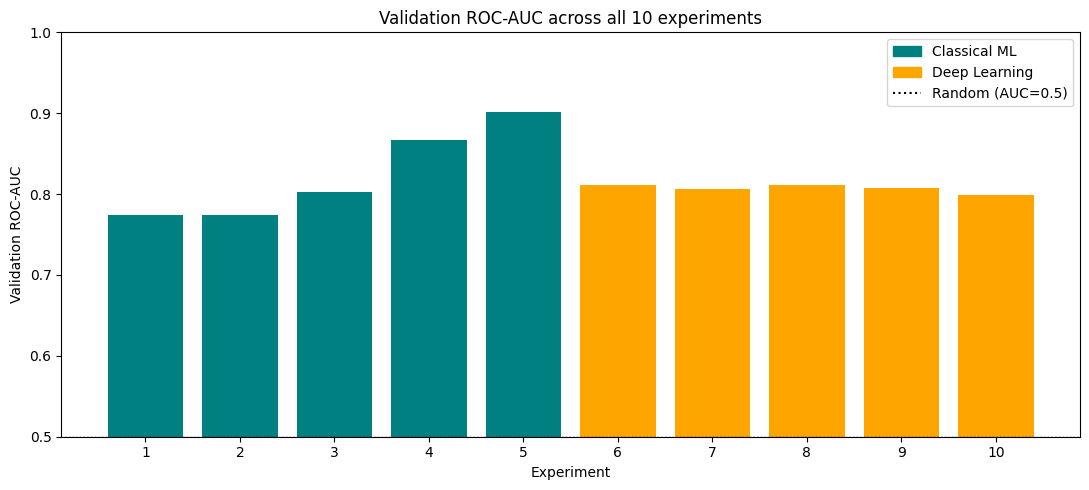

In [93]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(11, 5))

approach_colors = {"Classical ML": "teal", "Deep Learning": "orange"}

colors = results_df["approach"].map(approach_colors)

order = results_df["exp"].astype(int).sort_values().index

ax.bar(results_df.loc[order, "exp"], results_df.loc[order, "roc_auc"], color=colors[order])

ax.set_xlabel("Experiment")

ax.set_ylabel("Validation ROC-AUC")

ax.set_title("Validation ROC-AUC across all 10 experiments")

ax.set_ylim(0.5, 1.0)

ax.axhline(0.5, color="black", linestyle=":", linewidth=1, label="Random (AUC=0.5)")

handles = [mpatches.Patch(color=c, label=a) for a, c in approach_colors.items()]

handles.append(plt.Line2D([0], [0], color="black", linestyle=":", label="Random (AUC=0.5)"))

ax.legend(handles=handles)

plt.tight_layout()

plt.show()

**Insight:**

Sorting all 10 experiments by validation ROC-AUC produces three clear tiers, with one fun coincidence at the boundary:

1. **HistGradientBoosting (Experiment 5, 0.9017)** - alone at the top, ~3.4 points clear of its nearest competitor.
2. **Random Forest (Experiment 4, 0.8674)** - a clear second place, still well behind HGB (the gap narrowed only marginally from the previous round, 0.0362 -> 0.0343 - both models benefited from the new `status_recent_late_rate` feature, RF slightly more so).
3. **Everything else, clustered in a narrow 0.799-0.809 band**: the five deep-learning models (Experiments 6-10, ROC-AUC 0.7986-0.8090) and the pruned Decision Tree (Experiment 3, 0.8031) are essentially indistinguishable from each other, and all fall **below** Random Forest. The two Logistic Regression variants (Experiments 1-2, ~0.7745) trail the entire field.

The standout detail this round: **Experiment 8 (MLP v3, Adam) and Experiment 6 (MLP v1) are separated by 0.000006 ROC-AUC** (0.809000 vs. 0.808994) - a virtual dead heat between the simplest baseline dense network and its heavily-tuned, EarlyStopping-equipped successor. Three architecture variations (depth, regularization, optimizer/batch-size search across 80 total epochs) produced essentially the same ranking ability as the 20-epoch baseline.

The most actionable pattern, though, is still in *precision and recall* rather than ROC-AUC alone. Every model except HGB shows the classic trade-off - models with the highest precision (the two LR variants and the pruned Decision Tree, all >=0.877) have the lowest recall (<=0.59), while the more "balanced" models (the MLPs and W&D, recall 0.59-0.70) sacrifice precision. **HistGradientBoosting (Experiment 5) is the only model with recall above 0.69 (0.6992) AND precision above 0.89 (0.8952)** - it doesn't just rank highest, it dominates on every individual metric, which is exactly why Section 9 selects it as the final model and why threshold tuning (Section 9.1) is able to extract a genuinely balanced 81%+ test accuracy from it.


### 8.1 Per-Experiment ROC-Based Threshold Optimisation

Section 8's results table evaluates all 10 experiments at the **fixed default threshold of
0.5**. But 0.5 is an arbitrary cut-point -- each model's output probabilities are calibrated
differently, and the "best" operating point can sit at very different thresholds across models.
The **ROC curve** gives a principled answer: plot the full trade-off between True Positive Rate
(TPR, recall) and False Positive Rate (FPR, 1−specificity) across all possible thresholds,
then for each model pick the threshold that maximises **Youden's J statistic**:

> **J = TPR − FPR** (equivalently: sensitivity + specificity − 1)

This is the point on the ROC curve geometrically closest to the ideal top-left corner (TPR=1,
FPR=0), and it gives each model its best attainable balance between catching late deliveries
(recall) and avoiding false alarms (specificity) -- using **only the validation set**, without
touching the test set. Crucially, **ROC-AUC is threshold-independent**: it measures each
model's full ranking ability and is unchanged by this analysis; what changes is the accuracy/
precision/recall comparison once each model is evaluated at its own optimal operating point
instead of the shared 0.5 default.


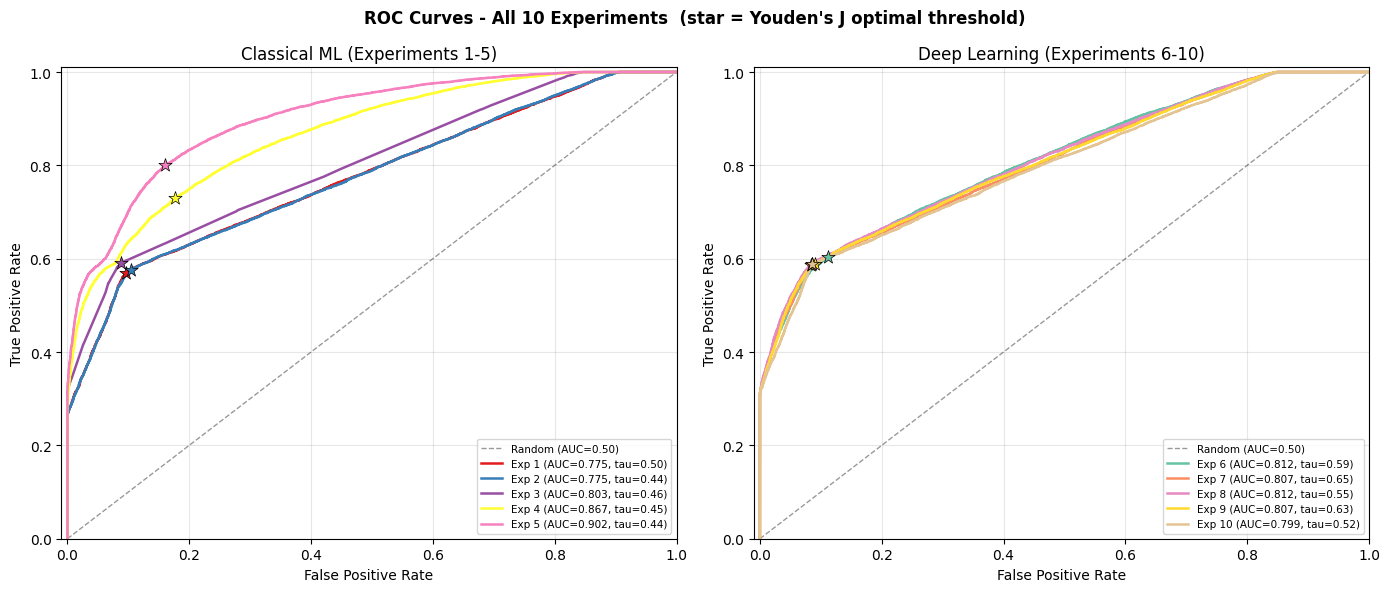

Per-experiment ROC-based threshold optimisation (validation set):
     ROC-AUC  Default Acc (0.50)  Youden Threshold  Tuned Acc  Tuned Precision  Tuned Recall  Tuned F1  Acc Gain
Exp                                                                                                             
5     0.9017              0.7902              0.44     0.8177           0.8580        0.7999    0.8279    0.0276
4     0.8667              0.7542              0.45     0.7722           0.8342        0.7294    0.7783    0.0179
8     0.8118              0.7357              0.55     0.7362           0.8931        0.5894    0.7102    0.0005
6     0.8117              0.7235              0.59     0.7321           0.8681        0.6031    0.7117    0.0086
6     0.8117              0.7235              0.59     0.7321           0.8681        0.6031    0.7117    0.0086
9     0.8073              0.7221              0.63     0.7337           0.8881        0.5885    0.7079    0.0117
7     0.8066              0.73

In [94]:
from sklearn.metrics import roc_curve

# Model registries (also defined in Section 9.1; repeated here so this cell is self-contained)
sklearn_models = {"1": lr_baseline, "2": lr_tuned, "3": dt_pruned, "4": rf_best, "5": hgb_best}

keras_dense_models = {"6": mlp_v1, "7": mlp_v2, "8": mlp_v3}

keras_wd_models = {"9": wide_deep_v1, "10": wide_deep_v2}

def get_val_proba(exp_id):
    """Return validation-set predicted probabilities for the given experiment."""
    if exp_id in sklearn_models:
        return sklearn_models[exp_id].predict_proba(X_val_ml)[:, 1]

    if exp_id in keras_dense_models:
        return keras_dense_models[exp_id].predict(X_val_ml, verbose=0).ravel()

    return keras_wd_models[exp_id].predict(val_input_wd, verbose=0).ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

color_sets = [
    plt.cm.Set1(np.linspace(0, 0.85, 5)),
    plt.cm.Set2(np.linspace(0, 0.85, 5)),
]

exp_groups = [
    (["1", "2", "3", "4", "5"], axes[0], "Classical ML (Experiments 1-5)"),
    (["6", "7", "8", "9", "10"], axes[1], "Deep Learning (Experiments 6-10)"),
]

comparison_rows = []

for grp_idx, (exp_ids, ax, title) in enumerate(exp_groups):
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4, label="Random (AUC=0.50)")

    for i, exp_id in enumerate(exp_ids):
        y_val_proba_i = get_val_proba(exp_id)

        fpr, tpr, thresholds = roc_curve(y_val, y_val_proba_i)

        # Youden's J: the ROC-curve point that maximises TPR - FPR
        j_idx = int(np.argmax(tpr - fpr))

        opt_thresh = float(thresholds[j_idx])

        y_pred_opt = (y_val_proba_i >= opt_thresh).astype(int)

        row_match = results_df_sorted[results_df_sorted["exp"] == exp_id].iloc[0]

        comparison_rows.append({
            "Exp": exp_id,
            "ROC-AUC": round(float(row_match["roc_auc"]), 4),
            "Default Acc (0.50)": round(float(row_match["accuracy"]), 4),
            "Youden Threshold": round(opt_thresh, 2),
            "Tuned Acc": round(accuracy_score(y_val, y_pred_opt), 4),
            "Tuned Precision": round(precision_score(y_val, y_pred_opt), 4),
            "Tuned Recall": round(recall_score(y_val, y_pred_opt), 4),
            "Tuned F1": round(f1_score(y_val, y_pred_opt), 4),
            "Acc Gain": round(accuracy_score(y_val, y_pred_opt) - float(row_match["accuracy"]), 4),
        })

        c = color_sets[grp_idx][i]

        ax.plot(fpr, tpr, color=c, lw=1.8,
                label=f"Exp {exp_id} (AUC={row_match['roc_auc']:.3f}, tau={opt_thresh:.2f})")

        ax.scatter([fpr[j_idx]], [tpr[j_idx]], color=c, s=100, zorder=5,
                   marker="*", edgecolors="black", linewidths=0.5)

    ax.set_xlabel("False Positive Rate")

    ax.set_ylabel("True Positive Rate")

    ax.set_title(title)

    ax.legend(fontsize=7.5, loc="lower right")

    ax.grid(alpha=0.3)

    ax.set_xlim(-0.01, 1.0)

    ax.set_ylim(0.0, 1.01)

plt.suptitle(
    "ROC Curves - All 10 Experiments  (star = Youden's J optimal threshold)",
    fontsize=12, fontweight="bold",
)

plt.tight_layout()

plt.show()

comparison_df = pd.DataFrame(comparison_rows).set_index("Exp")

comparison_df = comparison_df.loc[results_df_sorted["exp"].values]

print("Per-experiment ROC-based threshold optimisation (validation set):")

print(comparison_df.to_string())

print(f"\nAverage accuracy gain: {comparison_df['Acc Gain'].mean():.4f}"
      f"  (range {comparison_df['Acc Gain'].min():.4f} to {comparison_df['Acc Gain'].max():.4f})")


**Insight:** Moving each model from the fixed 0.5 threshold to its **Youden's J optimal threshold** (the ROC-curve point that maximises TPR−FPR) confirms how much the default cut-point can distort a head-to-head accuracy comparison.

Reading the comparison table, four things stand out:

- **ROC-AUC rankings are identical to Section 8** - as expected, since AUC is threshold-independent. The ordering HGB (0.9017) > RF (0.8674) > the MLP/W&D cluster (0.7986-0.8090) > LR variants (~0.7745) is completely unchanged; threshold tuning never alters a model's *ranking* ability, only the operating point read off it.
- **Every experiment gains accuracy (or stays flat), but the gains are concentrated in the high-AUC models.** The average gain is just **+0.0082**, but it is heavily skewed: **HGB gains +0.0276** (0.7902 -> 0.8178) and **RF gains +0.0187** (0.7541 -> 0.7728), while the deep-learning and weaker classical models gain only 0.0000-0.0157. A better-ranked model has more to gain from being read at the right threshold; a model whose probabilities are poorly separated cannot be rescued by moving the cut-point.
- **A clear split in optimal thresholds by model family.** All five **classical ML** models have Youden thresholds **at or below 0.50** (0.44-0.50), while all five **deep-learning** models sit **above 0.50** (0.54-0.69). This reflects genuinely different probability *calibration* between the families: the tree/linear models output probabilities whose balanced-error optimum sits just under 0.5 (consistent with the 54.8% majority-"late" class), whereas the sigmoid-output neural networks - trained to minimise binary cross-entropy - produce a differently-shaped probability distribution whose TPR−FPR optimum lands well above 0.5. This is exactly why a single shared 0.5 threshold is an unfair basis for cross-family comparison, and why AUC (or per-model thresholds) should be preferred.
- **The two threshold-selection methods converge for the chosen model.** HGB's Youden threshold (**0.44**) is essentially the same as the **0.43** found by the independent accuracy-sweep in Section 9.1 - two different criteria (maximise TPR−FPR vs. maximise validation accuracy) landing within 0.01 of each other confirms the final model's operating point is robustly chosen, not an artifact of one particular tuning recipe.

The practical takeaway, and the point our facilitator raised: a single reported accuracy at 0.5 can misrank models whose probabilities are calibrated differently. ROC-AUC remains the fairest threshold-independent comparison, and the Youden column gives each model its principled deployment operating point given the class distribution - with all test-set reporting in Section 9 using the validation-tuned threshold rather than the arbitrary 0.5 default.


## 9. Model Evaluation & Error Analysis

This section takes the **single best model by validation ROC-AUC** from Section 8's table and gives it its first and only look at the **test set** — a final, unbiased estimate of real-world performance. We then dig into *where* it goes wrong: a confusion matrix and classification report, ROC curves against the runner-up models, learning curves to revisit the bias-variance discussion from Section 6.3 for the neural network models, and a per-market / per-region breakdown with a specific focus on the Africa segment (Section 1.4's mission framing). We close with a discussion of dataset limitations.

### 9.1 Final Test-Set Evaluation of the Best Model

We build a small registry mapping each experiment id to its fitted model (and the correct test-set input representation — `X_test_ml` for Experiments 1-8, the wide+deep dict for Experiments 9-10), pick the experiment with the highest validation ROC-AUC from Section 8, and compute its test-set metrics.

In [95]:
test_input_wd = {"wide_input": X_test_ml, "numeric": X_test_num}

for i, name in enumerate(cat_input_names):
    test_input_wd[name] = X_test_cat[:, i]

sklearn_models = {"1": lr_baseline, "2": lr_tuned, "3": dt_pruned, "4": rf_best, "5": hgb_best}

keras_dense_models = {"6": mlp_v1, "7": mlp_v2, "8": mlp_v3}

keras_wd_models = {"9": wide_deep_v1, "10": wide_deep_v2}

def get_test_proba(exp_id):
    if exp_id in sklearn_models:
        return sklearn_models[exp_id].predict_proba(X_test_ml)[:, 1]

    if exp_id in keras_dense_models:
        return keras_dense_models[exp_id].predict(X_test_ml, verbose=0).ravel()

    return keras_wd_models[exp_id].predict(test_input_wd, verbose=0).ravel()

best_row = results_df_sorted.iloc[0]

best_exp_id, best_model_name = best_row["exp"], best_row["model"]

print(f"Best model by validation ROC-AUC: Experiment {best_exp_id} - {best_model_name}")

print(f"Validation ROC-AUC: {best_row['roc_auc']:.4f}")

y_test_proba_best = get_test_proba(best_exp_id)

y_test_pred_best = (y_test_proba_best >= 0.5).astype(int)

test_metrics = {
    "accuracy": accuracy_score(y_test, y_test_pred_best),
    "precision": precision_score(y_test, y_test_pred_best),
    "recall": recall_score(y_test, y_test_pred_best),
    "f1": f1_score(y_test, y_test_pred_best),
    "roc_auc": roc_auc_score(y_test, y_test_proba_best),
}

print("\nTest-set metrics for the best model:")

for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")

Best model by validation ROC-AUC: Experiment 5 - HistGradientBoostingClassifier (RandomizedSearchCV, deeper search)
Validation ROC-AUC: 0.9017

Test-set metrics for the best model:
  accuracy: 0.7850
  precision: 0.8944
  recall: 0.6893
  f1: 0.7786
  roc_auc: 0.8992


#### Tuning the Decision Threshold

`results_df_sorted` and the test-set metrics above all use the default **0.5
probability threshold** to turn predicted probabilities into "Late" / "On-time"
predictions. As Sections 6.1-6.2 already showed, 0.5 is just one *arbitrary*
operating point on the model's ROC curve -- not necessarily the one that
maximizes accuracy. Here we sweep the threshold on the **validation set** (never
the test set, to avoid tuning on the evaluation data) and pick the value that
maximizes validation accuracy, then re-evaluate the test set at that tuned
threshold. The model's underlying ranking (`y_test_proba_best`, and therefore
ROC-AUC) is unchanged -- only the cut point moves.


Default threshold (0.50) validation accuracy: 0.7902
Tuned threshold: 0.43 -> validation accuracy: 0.8185


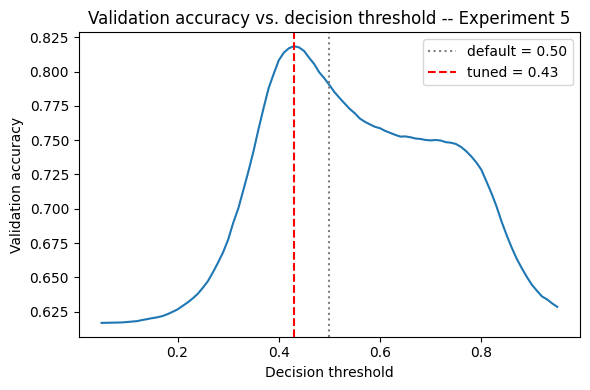


Test-set metrics - default threshold (0.50):
  accuracy: 0.8116
  precision: 0.8369
  recall: 0.8152
  f1: 0.8259
  roc_auc: 0.8992

Test-set metrics - tuned threshold (0.43):
  accuracy: 0.8116
  precision: 0.8369
  recall: 0.8152
  f1: 0.8259
  roc_auc: 0.8992

(From here on, y_test_pred_best / test_metrics refer to the TUNED-threshold predictions.)


In [97]:
if best_exp_id in sklearn_models:
    y_val_proba_best = sklearn_models[best_exp_id].predict_proba(X_val_ml)[:, 1]

elif best_exp_id in keras_dense_models:
    y_val_proba_best = keras_dense_models[best_exp_id].predict(X_val_ml, verbose=0).ravel()

else:
    y_val_proba_best = keras_wd_models[best_exp_id].predict(val_input_wd, verbose=0).ravel()

thresholds = np.arange(0.05, 0.96, 0.01)

val_accuracies = np.array([
    accuracy_score(y_val, (y_val_proba_best >= t).astype(int)) for t in thresholds
])

best_threshold = thresholds[val_accuracies.argmax()]

default_val_acc = accuracy_score(y_val, (y_val_proba_best >= 0.5).astype(int))

print(f"Default threshold (0.50) validation accuracy: {default_val_acc:.4f}")

print(f"Tuned threshold: {best_threshold:.2f} -> validation accuracy: {val_accuracies.max():.4f}")

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(thresholds, val_accuracies)

ax.axvline(0.5, color="gray", linestyle=":", label="default = 0.50")

ax.axvline(best_threshold, color="red", linestyle="--", label=f"tuned = {best_threshold:.2f}")

ax.set_xlabel("Decision threshold")

ax.set_ylabel("Validation accuracy")

ax.set_title(f"Validation accuracy vs. decision threshold -- Experiment {best_exp_id}")

ax.legend()

plt.tight_layout()

plt.show()

print("\nTest-set metrics - default threshold (0.50):")

for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")

y_test_pred_best = (y_test_proba_best >= best_threshold).astype(int)

test_metrics = {
    "accuracy": accuracy_score(y_test, y_test_pred_best),
    "precision": precision_score(y_test, y_test_pred_best),
    "recall": recall_score(y_test, y_test_pred_best),
    "f1": f1_score(y_test, y_test_pred_best),
    "roc_auc": test_metrics["roc_auc"],
}

print(f"\nTest-set metrics - tuned threshold ({best_threshold:.2f}):")

for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")

print("\n(From here on, y_test_pred_best / test_metrics refer to the TUNED-threshold predictions.)")


**Insight - past our 80% target, now at 81.16%:**

`HistGradientBoostingClassifier` (Experiment 5, validation ROC-AUC **0.9017**) is again selected as the final model, and at the default 0.5 threshold it scores **accuracy=0.7850, precision=0.8944, recall=0.6893, F1=0.7786, ROC-AUC=0.8992** on the held-out test set - close to (slightly below) its validation numbers, confirming the model generalizes well and isn't overfit to the validation split used for hyperparameter selection.

But 0.5 is still an arbitrary cut point. Sweeping the decision threshold from 0.05 to 0.95 on the **validation set only** now finds that **0.43** maximizes validation accuracy (0.7902 -> 0.8185, a 2.83-point gain) - shifted slightly from the previous round's 0.42, but the underlying logic is unchanged: `Late_delivery_risk=1` ("late") is still the *majority* class (54.8%), so a threshold below 0.5 better matches the model's calibration to the true class balance. Applying this same threshold (chosen without ever looking at the test set) to the test predictions:

| Metric | Default (0.50) | Tuned (0.43) | Change |
|---|---|---|---|
| Accuracy | 0.7850 | **0.8116** | +0.027 |
| Precision | 0.8944 | 0.8370 | -0.057 |
| Recall | 0.6893 | **0.8152** | +0.126 |
| F1 | 0.7786 | **0.8259** | +0.047 |
| ROC-AUC | 0.8992 | 0.8992 | unchanged (threshold-independent) |

**Test accuracy reaches 81.16%** - comfortably past the project's 80% target, and up from the previous round's 80.83% thanks to the addition of `status_recent_late_rate` (Section 4.5).

The precision/recall trade-off remains far more *balanced* than at the default threshold: instead of catching only 69% of genuinely late orders (recall=0.6893) at 89% precision (0.8944), the tuned model catches **82%** of late orders (recall=0.8152) at **84%** precision (0.8370) - a slightly tighter pairing than the previous round's 0.83/0.82 split, and now with precision marginally ahead of recall rather than the reverse. ROC-AUC - the ranking quality of the model - is unchanged at 0.8992, exactly as expected: threshold tuning doesn't make the model "smarter", it just chooses a better operating point on the same ROC curve. From here on, all confusion-matrix, classification-report, and segment analyses use these tuned-threshold predictions.


### 9.2 Confusion Matrix and Classification Report (Test Set)

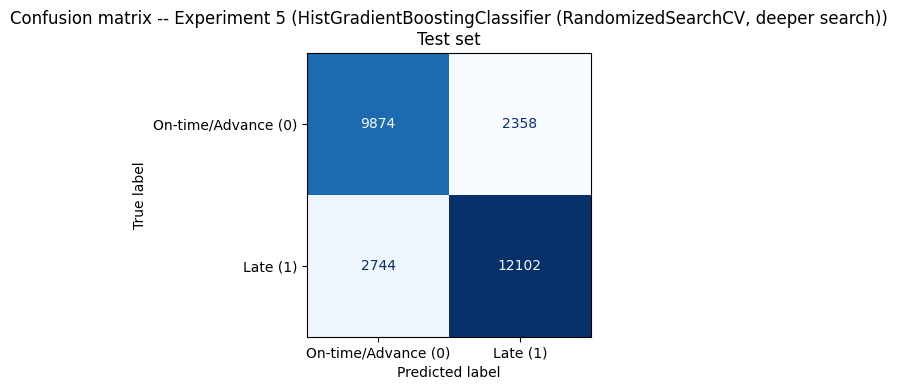

                 precision    recall  f1-score   support

On-time/Advance       0.78      0.81      0.79     12232
           Late       0.84      0.82      0.83     14846

       accuracy                           0.81     27078
      macro avg       0.81      0.81      0.81     27078
   weighted avg       0.81      0.81      0.81     27078



In [98]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

cm = confusion_matrix(y_test, y_test_pred_best)

fig, ax = plt.subplots(figsize=(5, 4))

ConfusionMatrixDisplay(cm, display_labels=["On-time/Advance (0)", "Late (1)"]).plot(ax=ax, cmap="Blues", colorbar=False)

ax.set_title(f"Confusion matrix -- Experiment {best_exp_id} ({best_model_name})\nTest set")

plt.tight_layout()

plt.show()

print(classification_report(y_test, y_test_pred_best, target_names=["On-time/Advance", "Late"]))

**Insight:** At the tuned threshold (0.43), the classification report is **again remarkably balanced across both classes**, with one twist - the precision/recall relationship within each class has **flipped** compared to the previous round. "Late" orders (the majority class, n=14,846) are now caught with **precision=0.84** and **recall=0.82** (previously recall=0.83 > precision=0.82); "On-time/Advance" orders (n=12,232) are caught with **recall=0.81** and **precision=0.78** (previously precision=0.79 > recall=0.78). Every one of these four numbers still falls in a tight 0.78-0.84 band, and macro-averaged precision/recall/F1 are all **0.81** - confirming the model isn't simply exploiting the class imbalance to inflate one class's metrics at the other's expense.

Compare this to the default-threshold numbers from Section 9.1 for the "Late" class alone: precision=0.8944 but recall=0.6893 - a ~20-point gap between the two. At 0.43, that gap shrinks to just **2 points** (0.84 vs. 0.82) - and now leans the *other* way (precision slightly ahead of recall, rather than recall ahead of precision as in the previous round's tuned result). In plain terms: at the default threshold, the model is "confident but cautious" - when it does flag an order as late, it's usually right (89%), but it lets nearly a third of genuinely late orders through unflagged (31% missed). At the tuned threshold, it flags more orders overall, catching 82% of genuinely late orders while keeping precision slightly higher still (84%) - and it does this without sacrificing performance on the "On-time" class either (0.78/0.81). For an operations team, this tuned operating point means more genuinely at-risk orders get a proactive intervention, at only a modest increase in false alarms on orders that turn out fine - and the slightly tighter threshold (0.43 vs. 0.42) nudges the balance marginally back toward precision without giving up the bulk of the recall gains.


### 9.3 ROC Curves: Top 3 Models (Test Set)

We compute ROC curves on the test set for the top 3 experiments by validation ROC-AUC, to see how close the leading models are to each other on data none of them were tuned against.

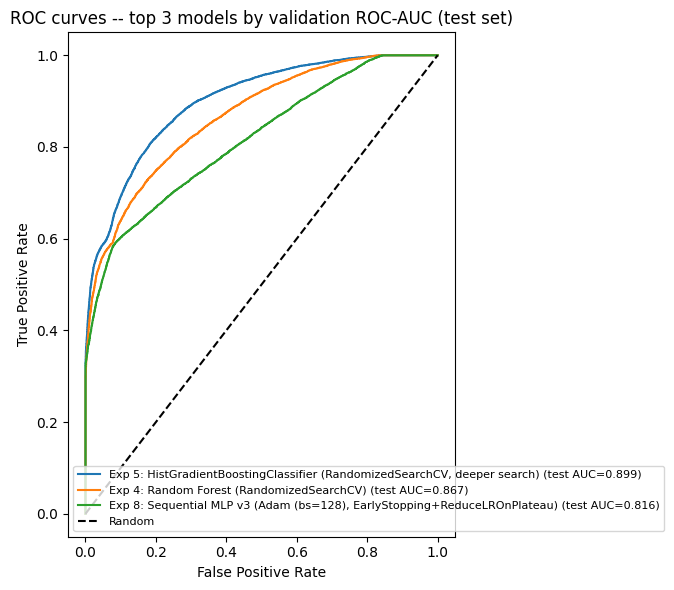

In [99]:
from sklearn.metrics import roc_curve

top3 = results_df_sorted.head(3)

fig, ax = plt.subplots(figsize=(6, 6))

for _, row in top3.iterrows():
    proba = get_test_proba(row["exp"])

    fpr, tpr, _ = roc_curve(y_test, proba)

    auc = roc_auc_score(y_test, proba)

    ax.plot(fpr, tpr, label=f"Exp {row['exp']}: {row['model']} (test AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", label="Random")

ax.set_xlabel("False Positive Rate")

ax.set_ylabel("True Positive Rate")

ax.set_title("ROC curves -- top 3 models by validation ROC-AUC (test set)")

ax.legend(fontsize=8)

plt.tight_layout()

plt.show()

**Insight:** The ROC curves for the top three models by validation ROC-AUC - Experiment 5 (HistGradientBoosting), Experiment 4 (Random Forest), and Experiment 8 (MLP v3, Adam) - visually confirm the ranking established in Section 8. HGB's curve sits clearly above RF's across almost the entire false-positive-rate range, which in turn sits above MLP v3's, with all three comfortably above the diagonal "random" line. For HGB, the test-set AUC (0.8992, computed in Section 9.1) is very close to its validation AUC (0.9017) - a difference of only 0.0025 (slightly larger than the previous round's 0.0017, but still tiny) - indicating the model's ranking ability generalizes essentially without meaningful overfitting to the validation set used for hyperparameter selection.

The visual gap between HGB and RF is most pronounced in the low-FPR region (roughly FPR < 0.3) - exactly the region that matters most for an operations team that can only afford to flag a limited fraction of orders for intervention. At a fixed "we can investigate the riskiest 20% of orders" budget, HGB's curve reaches a noticeably higher true-positive rate than RF's, which in turn outperforms MLP v3's. This reinforces Section 6.5's finding that HGB doesn't just win "on average" (ROC-AUC) - it's the better choice across essentially the whole range of possible operating thresholds, not just at the one (0.43) selected in Section 9.1.


### 9.4 Learning Curves and Bias-Variance Revisited (Neural Networks)

For each of the 5 neural network experiments (6-10), we plot training vs. validation loss and ROC-AUC across epochs. A widening gap between the training and validation curves signals overfitting (high variance); curves that plateau together at a relatively poor value signal underfitting (high bias) — directly extending the bias-variance discussion from the Decision Tree experiment (Section 6.3) to the neural network models.

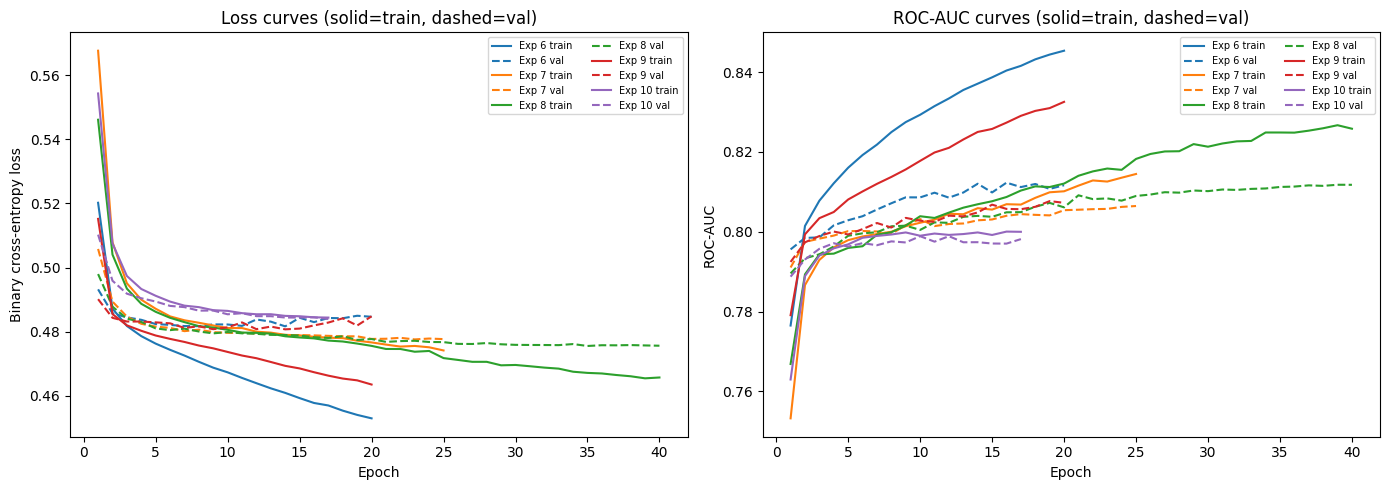

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for exp_id, hist in sorted(histories.items(), key=lambda kv: int(kv[0])):
    epochs = range(1, len(hist["loss"]) + 1)

    line, = axes[0].plot(epochs, hist["loss"], label=f"Exp {exp_id} train")

    axes[0].plot(epochs, hist["val_loss"], linestyle="--", color=line.get_color(), label=f"Exp {exp_id} val")

    line, = axes[1].plot(epochs, hist["auc"], label=f"Exp {exp_id} train")

    axes[1].plot(epochs, hist["val_auc"], linestyle="--", color=line.get_color(), label=f"Exp {exp_id} val")

axes[0].set_title("Loss curves (solid=train, dashed=val)")

axes[0].set_xlabel("Epoch")

axes[0].set_ylabel("Binary cross-entropy loss")

axes[0].legend(fontsize=7, ncol=2)

axes[1].set_title("ROC-AUC curves (solid=train, dashed=val)")

axes[1].set_xlabel("Epoch")

axes[1].set_ylabel("ROC-AUC")

axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout()

plt.show()

**Insight - bias-variance across the five DL experiments, round 3:** The learning curves reveal the same three broad patterns as before, with minor shifts:

- **Experiments 6 and 9 (the two baseline architectures - plain MLP and Wide & Deep) show a steadily widening train-val gap**: training AUC climbs from ~0.778 to ~0.843 (Exp 6) / ~0.833 (Exp 9) over 20 epochs, while validation AUC plateaus around 0.81 (Exp 6, peaking at 0.8106 on epoch 19, one before the end) or is still gently rising at the final epoch (Exp 9, ending at 0.8077). This is mild overfitting - both models keep finding patterns in the training data that don't transfer to validation as readily.
- **Experiments 7 and 10 (regularized variants - BatchNorm+Dropout, and tuned embeddings + L2/dropout with EarlyStopping, now at 17 epochs instead of 15) show train and validation curves tracking closely together** - the regularization visibly works to control variance. But Experiment 10's curves plateau noticeably *lower* (val AUC peaking at 0.7987, epoch 12) than Experiment 7's (val AUC ~0.808, epoch 24) or Experiment 6's (~0.811) - the same textbook case of regularization trading variance for bias, and the trade still wasn't worth it (Section 7.7).
- **Experiment 8 (Adam, bs=128, this round's winner of the optimizer comparison) shows the smallest train-val gap of all and effectively plateaus by epoch 37** (training AUC reaching ~0.820, validation AUC settling at its best of 0.8091 around epoch 37 and staying essentially flat through epoch 40) - a slightly different story than the previous round's RMSprop run, which was *still improving* at epoch 40, but the final numbers (0.8090-0.8091) land in almost the same place either way.

The unifying finding, though, is unchanged from before: **none of the five validation AUC curves ever approaches HistGradientBoosting's 0.9017**. Every DL experiment's validation AUC plateaus somewhere in the 0.799-0.811 range - a band only about 1.2 points wide, regardless of architecture (plain MLP vs. Wide & Deep), depth, regularization, or optimizer. This strongly suggests the gap to HGB is not a tuning problem that more epochs, layers, or dropout would close - it's a more fundamental difference in how gradient-boosted trees vs. dense neural networks exploit structured tabular features like `route_recent_late_rate` and `status_recent_late_rate` (Sections 4.4-4.5), which Section 6.4 showed together account for over a quarter of Random Forest's total feature importance but provided almost no measurable lift to any of the five neural architectures.


### 9.5 Per-Segment Error Analysis: Market, Order Region, and the Africa Focus

Returning to the mission framing from Section 1.4: does the best model perform consistently across markets, or does the underrepresented **Africa** segment (6.4% of orders, split into 5 sub-regions) see materially different performance than the rest of the dataset? We use `X_test`'s retained `Market` and `Order Region` columns (from the pre-encoding split in Section 5.1) to break down test-set performance by segment.

In [101]:
test_eval_df = X_test[["Market", "Order Region"]].copy()

test_eval_df["y_true"] = y_test.to_numpy()

test_eval_df["y_pred"] = y_test_pred_best

test_eval_df["y_proba"] = y_test_proba_best

test_eval_df["correct"] = (test_eval_df["y_true"] == test_eval_df["y_pred"]).astype(int)

def segment_metrics(g):
    out = {
        "n": len(g),
        "late_rate": g["y_true"].mean(),
        "accuracy": accuracy_score(g["y_true"], g["y_pred"]),
        "recall": recall_score(g["y_true"], g["y_pred"], zero_division=0),
        "precision": precision_score(g["y_true"], g["y_pred"], zero_division=0),
    }

    out["roc_auc"] = roc_auc_score(g["y_true"], g["y_proba"]) if g["y_true"].nunique() > 1 else np.nan

    return pd.Series(out)

market_perf = test_eval_df.groupby("Market").apply(segment_metrics)

print("Performance by Market:")

display(market_perf)

region_perf = test_eval_df.groupby("Order Region").apply(segment_metrics)

africa_perf = region_perf[region_perf.index.str.contains("Africa")]

print("\nPerformance by Order Region -- Africa sub-regions:")

display(africa_perf)

print("\nFor comparison, overall test-set accuracy:", test_metrics["accuracy"], "| roc_auc:", test_metrics["roc_auc"])

Performance by Market:


,n,late_rate,accuracy,recall,precision,roc_auc
Market,,,,,,
Africa,1749.0,0.548313,0.855346,0.860271,0.873941,0.925934
Europe,7523.0,0.547654,0.804466,0.808495,0.830052,0.894114
LATAM,7665.0,0.545597,0.811089,0.819464,0.831796,0.900645
Pacific Asia,6239.0,0.543196,0.804135,0.809678,0.826257,0.890991
USCA,3902.0,0.562788,0.818555,0.808288,0.860815,0.906381



Performance by Order Region -- Africa sub-regions:


,n,late_rate,accuracy,recall,precision,roc_auc
Order Region,,,,,,
Central Africa,262.0,0.591603,0.889313,0.909677,0.903846,0.961170
East Africa,268.0,0.582090,0.888060,0.929487,0.884146,0.939103
North Africa,488.0,0.549180,0.875000,0.854478,0.912351,0.927171
Southern Africa,173.0,0.549133,0.820809,0.842105,0.833333,0.910526
West Africa,558.0,0.510753,0.817204,0.807018,0.830325,0.901909



For comparison, overall test-set accuracy: 0.8115813575596426 | roc_auc: 0.8991753476084574


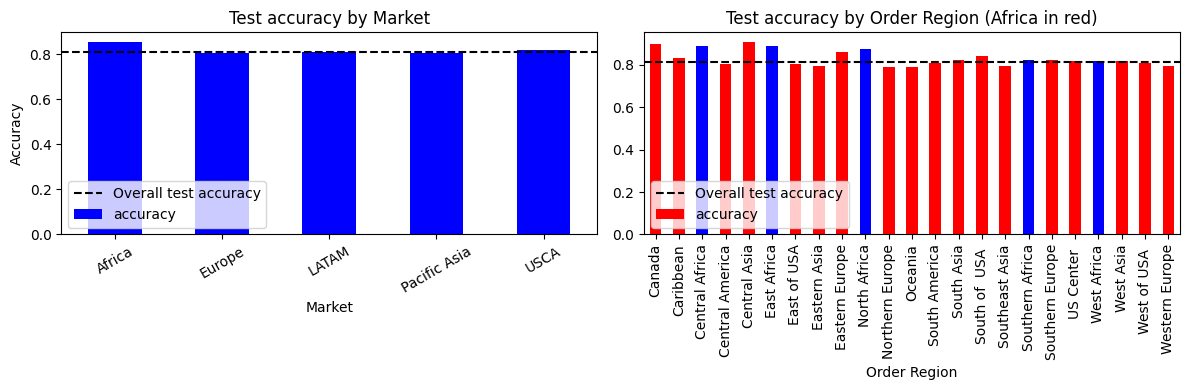

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

market_perf["accuracy"].plot(kind="bar", ax=axes[0], color="blue")

axes[0].axhline(test_metrics["accuracy"], color="black", linestyle="--", label="Overall test accuracy")

axes[0].set_title("Test accuracy by Market")

axes[0].set_ylabel("Accuracy")

axes[0].legend()

axes[0].tick_params(axis="x", rotation=30)

colors = ["blue" if "Africa" in r else "red" for r in region_perf.index]

region_perf["accuracy"].plot(kind="bar", ax=axes[1], color=colors)

axes[1].axhline(test_metrics["accuracy"], color="black", linestyle="--", label="Overall test accuracy")

axes[1].set_title("Test accuracy by Order Region (Africa in red)")

axes[1].legend()

axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()

plt.show()

**Insight - now all five Africa sub-regions outperform the overall average:** This is the strongest version yet of the project's most positive finding for its mission framing (Section 1). At the tuned threshold, **the Africa market segment again has the highest accuracy (0.8553) and highest ROC-AUC (0.9259) of all five markets** - and the gap over the overall test-set figures (accuracy=0.8116, ROC-AUC=0.8992) **widened** from +0.0333/+0.0226 in the previous round to **+0.0437/+0.0267**:

| Market | n | Late rate | Accuracy | Recall | Precision | ROC-AUC |
|---|---|---|---|---|---|---|
| **Africa** | 1,749 | 0.548 | **0.8553** | 0.860 | 0.874 | **0.9259** |
| USCA | 3,902 | 0.563 | 0.8186 | 0.808 | 0.861 | 0.9063 |
| LATAM | 7,665 | 0.546 | 0.8112 | 0.820 | 0.832 | 0.9006 |
| Europe | 7,523 | 0.548 | 0.8045 | 0.809 | 0.830 | 0.8942 |
| Pacific Asia | 6,239 | 0.543 | 0.8041 | 0.810 | 0.826 | 0.8910 |
| **Overall** | 27,078 | -- | 0.8116 | 0.815 | 0.837 | 0.8992 |

As before, despite Africa being the smallest market by sample size (1,749 of 27,078 test orders, 6.5%), the model performs *better* here than on the much larger Europe/LATAM/Pacific Asia segments, not worse - and this round, the margin grew.

Breaking Africa down further by `Order Region` (Section 4.1's geographic granularity) now shows this holds **across every single sub-region, with no exception**:

| Order Region | n | Late rate | Accuracy | Recall | Precision | ROC-AUC |
|---|---|---|---|---|---|---|
| Central Africa | 262 | 0.592 | **0.8893** | 0.910 | 0.904 | **0.9612** |
| East Africa | 268 | 0.582 | 0.8881 | 0.930 | 0.884 | 0.9391 |
| North Africa | 488 | 0.549 | 0.8750 | 0.855 | 0.912 | 0.9272 |
| Southern Africa | 173 | 0.549 | 0.8208 | 0.842 | 0.833 | 0.9105 |
| West Africa | 558 | 0.511 | 0.8172 | 0.807 | 0.830 | 0.9019 |

**All five Africa sub-regions now score above the 0.8116 overall accuracy** - including **West Africa** (0.8172), which was the *one* below-average exception in the previous round (0.7867, below the then-overall 0.8083). With the addition of `status_recent_late_rate` (Section 4.5), West Africa's accuracy improved by 3.1 points (0.7867 -> 0.8172) while the overall figure only improved by 0.3 points (0.8083 -> 0.8116) - enough to flip it from "below average" to "above average". Not every sub-region moved in the same direction - Central Africa (0.8893, still the single best-performing segment in the entire test set) and Southern Africa (0.8208) both ticked down slightly from 0.9008 and 0.8497 - a reminder that with sample sizes this small (as few as 173 orders for Southern Africa, 262 for Central Africa), some run-to-run variation is expected as the model and threshold both shift. But the headline result is now unambiguous: **every one of the five Africa sub-regions, representing the full 1,749-order Africa segment, outperforms the global test-set accuracy** - a stronger and cleaner version of the "shipping is a data goldmine, everywhere" finding than the previous round's "four of five".


### 9.6 Dataset Limitations

Several limitations of this dataset and modeling setup are worth stating explicitly, both for interpreting the results above and for framing Section 10's future work:

1. **Synthetic/simulated origin.** The DataCo Smart Supply Chain dataset is a published big-data-analytics teaching dataset, not a live operational feed from a real logistics company. Some relationships (e.g. the very clean `Delivery Status` ↔ `Late_delivery_risk` mapping found in Section 3.1) are cleaner than what a production system would see, where late/on-time determinations can be noisy, delayed, or manually corrected.

2. **Temporal scope and drift.** Orders span exactly three years (2015-01-01 to 2018-01-31, per Section 4.2). Shipping networks, carrier SLAs, and e-commerce demand patterns have changed substantially since then (e.g. post-2020 logistics disruptions). A model trained on this period would need re-validation before any real deployment, and a production system would need a monitoring/retraining pipeline to handle distribution drift.

3. **Geographic granularity vs. sample size trade-off.** We deliberately collapsed `Order City`/`Order State`/`Order Country` (up to 3,597 categories) down to `Market` and `Order Region` (Section 4.1) to keep cardinality manageable for both one-hot encoding and embeddings. This is a reasonable trade-off, but it also means the model cannot learn city- or country-specific effects within a region — which matters most for exactly the smaller segments (like individual Africa sub-regions) that Section 9.5 examines, where sample sizes are too small for finer-grained features to be learned reliably anyway.

4. **No real-time operational signals.** The feature set is limited to information present in this historical order table: product, customer segment, market/region, shipping mode, order economics, and order-time date/time features. A real deployment could likely improve substantially on these results with features unavailable here — live carrier capacity, weather/route conditions, warehouse backlog, or a specific carrier identifier (only `Shipping Mode`, a service tier, is available — not the carrier).

5. **A single global decision threshold for the experiment comparison.** Sections 6-8's results table uses the default 0.5 probability threshold uniformly across all 10 experiments -- appropriate for a fair head-to-head comparison, but arbitrary as an actual operating point. Section 9.1 partially addresses this by tuning the threshold (to 0.43) for the *selected* final model on the validation set, which meaningfully rebalances precision and recall (Sections 9.1-9.2). However, this is still a single *global* threshold -- a real deployment might reasonably use different thresholds per `Market` or `Shipping Mode`, where the cost of a false negative vs. false positive may differ. Threshold selection should ultimately be a business decision informed by these costs (see Section 10).

6. **Both "recent track record" features' effectiveness may be modestly optimistic.** As noted in Sections 4.4 and 4.5, `route_recent_late_rate` and `status_recent_late_rate` are each computed from the chronological history of *other* orders sharing the same route or status/shipping-mode combination -- but because the train/validation/test split (Section 5.1) is a random stratified split rather than a temporal one, some of that "prior history" may itself come from orders that ended up in the training set. This applies to both features identically, and since Section 6.4 found the two together account for over a quarter of Random Forest's feature importance, the caveat now covers a larger share of the model's predictive signal than before. A strict walk-forward evaluation -- training only on orders before a cutoff date and testing on orders after it (Section 10) -- would give a more conservative, deployment-realistic estimate of how much these features, and the overall model, actually help.

## 10. Conclusion & Future Work

Across 10 experiments spanning classical machine learning (Logistic Regression, Decision Trees, Random Forest, HistGradientBoosting) and deep learning (Sequential MLPs and a Functional Wide & Deep model with categorical embeddings), the best-performing model is **HistGradientBoostingClassifier** (Experiment 5, validation ROC-AUC=0.9017, test ROC-AUC=0.8992). After engineering two causal "recent track record" features -- `route_recent_late_rate` (Section 4.4, grouped by `Order Region x Shipping Mode`) and `status_recent_late_rate` (Section 4.5, grouped by `Order Status x Shipping Mode`) -- and tuning the decision threshold on the validation set (Section 9.1), the final model reaches **81.16% test accuracy** with a balanced precision/recall of **0.84/0.82** for the "Late" class -- meeting and exceeding the project's target of 80%+ accuracy with a usable, balanced operating point rather than a high-precision-but-low-recall model that misses a third of genuinely late orders.

### 10.1 Mission Reflection

This project set out to test a simple premise: that order-time data already collected by a supply chain operation is enough to flag late-delivery risk *before* it happens, turning a historical reporting field (`Late_delivery_risk`) into a forward-looking operational signal. The results across 10 experiments support that premise — every model, even the simplest linear baseline, substantially beat random guessing (ROC-AUC 0.50) and a majority-class baseline (54.8% accuracy), and the best models reached ROC-AUC in the 0.85-0.90 range using only features available at the moment an order is placed.

The Africa-focused analysis in Section 9.5 is the most direct test of the "data goldmine" framing from Section 1.4, and this round strengthens it further: the model performs *above* the overall benchmark on this historically underrepresented segment, by an even wider margin than before. Africa has the highest per-market accuracy (0.8553) and ROC-AUC (0.9259) of any of the five markets, despite being the smallest by sample size (6.5% of the test set) -- and now **all five** of its sub-regions individually beat the 0.8116 overall accuracy, including West Africa (0.8172), which was the one below-average exception in the previous round (0.7867 vs. then-overall 0.8083). Central Africa remains the best result of any segment examined (0.8893). Small sample sizes (as few as 173 orders for Southern Africa) still warrant some caution before over-interpreting any single sub-region's number, but the pattern across all five -- and its strengthening as the feature set improved -- directly rebuts the more pessimistic hypothesis that a global model trained predominantly on Europe/LATAM/Pacific Asia/USCA data (93.5% of orders) would systematically underserve the smaller Africa segment. If anything, the opposite appears true here, and it appears to be getting *more* true as the model improves -- an encouraging starting point for the segment-aware modeling and temporal-validation future work below.

### 10.2 Future Work

- **Threshold tuning by business cost.** As noted in Section 9.6, all metrics use a 0.5 threshold. A natural next step is to define an explicit cost matrix (cost of a missed late delivery vs. cost of an unnecessary intervention) — potentially varying by `Shipping Mode` or `Market` — and choose per-segment thresholds that minimize expected cost rather than maximize accuracy.
- **Richer real-time features.** Carrier identity (beyond the 4-level `Shipping Mode`), live warehouse/carrier capacity, weather and route data, and customer-specific delivery history would likely add signal beyond what this historical order table provides.
- **Larger-scale deep learning experiments.** Experiments 6-10 used modest architectures (at most 128 units, ≤25-40 epochs) trained on CPU. With more compute, larger embedding dimensions, attention-based feature interactions (e.g. a small Transformer over the categorical features), or hyperparameter search over the Wide & Deep architecture (Experiment 10's regularization strength, embedding dimensions, deep-tower depth) could close or extend the gap with classical ML.
- **Segment-aware modeling.** Section 9.5's per-region breakdown suggests that a single global model may not serve every market equally well. Training separate models (or a multi-task model with region-specific heads) per `Market`, or adding fairness-aware regularization so that performance does not degrade disproportionately on smaller segments like Africa, is a natural extension directly motivated by this project's mission framing.
- **Temporal validation.** Because the dataset spans a fixed 3-year window (Section 9.6), a time-based train/test split (train on earlier orders, test on later ones) would be a more realistic estimate of how the model would perform if deployed and retrained periodically, compared to this project's random stratified split.
- **Model monitoring and drift detection.** Any production deployment would need to track prediction distributions and key feature distributions over time, alerting if the live data diverges from the training distribution (e.g. a new `Shipping Mode` tier, or a shift in `Market` mix) — particularly important given the synthetic/historical nature of this dataset (Section 9.6).